<a href="https://colab.research.google.com/github/AnjaliKM-S/ICT-AKM_2026/blob/main/WORK_SHEET_BENZENE_CONCENTRATION_PREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Libraries

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import GridSearchCV,TimeSeriesSplit, cross_val_score
from sklearn.model_selection import train_test_split

## Load Dataset

In [ ]:
file_path = '/content/drive/MyDrive/ICT_AKM26/PROJECT/AirQualityUCI.xlsx'

In [ ]:
df = pd.read_excel(file_path)
df.head(5)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,2.6,1360.00,150,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
1,2004-03-10,19:00:00,2.0,1292.25,112,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2,2004-03-10,20:00:00,2.2,1402.00,88,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
3,2004-03-10,21:00:00,2.2,1375.50,80,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
4,2004-03-10,22:00:00,1.6,1272.25,51,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794


In [ ]:
df.info()   # Display a summary of the DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           9357 non-null   datetime64[ns]
 1   Time           9357 non-null   object        
 2   CO(GT)         9357 non-null   float64       
 3   PT08.S1(CO)    9357 non-null   float64       
 4   NMHC(GT)       9357 non-null   int64         
 5   C6H6(GT)       9357 non-null   float64       
 6   PT08.S2(NMHC)  9357 non-null   float64       
 7   NOx(GT)        9357 non-null   float64       
 8   PT08.S3(NOx)   9357 non-null   float64       
 9   NO2(GT)        9357 non-null   float64       
 10  PT08.S4(NO2)   9357 non-null   float64       
 11  PT08.S5(O3)    9357 non-null   float64       
 12  T              9357 non-null   float64       
 13  RH             9357 non-null   float64       
 14  AH             9357 non-null   float64       
dtypes: datetime64[ns](1),

In [ ]:
print(f"Shape        : {df.shape}")   # Display row and column counts
print(f"Columns      : {df.columns.tolist()}")   # List all column names as an array

print(f"Date range   : {df['Date'].min().date()} → {df['Date'].max().date()}")    # Show start and end dates

Shape        : (9357, 15)
Columns      : ['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']
Date range   : 2004-03-10 → 2005-04-04


## EDA & Preprocessing

In [ ]:
# Checking for null values
df.isna().sum()

,0
Date,0
Time,0
CO(GT),0
PT08.S1(CO),0
NMHC(GT),0
C6H6(GT),0
PT08.S2(NMHC),0
NOx(GT),0
PT08.S3(NOx),0
NO2(GT),0


In [ ]:
# Checking for duplicate values
df.duplicated().sum()

np.int64(0)

In [ ]:
# Separate numerical and categorical column names from the DataFrame

num_cols=df.select_dtypes(include=['number']).columns
cat_cols=df.select_dtypes(include=['object']).columns

### Statistical Summary

In [ ]:
df.describe()

,Date,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9357,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,2004-09-21 04:30:05.193972480,-34.207524,1048.869652,-159.090093,1.865576,894.475963,168.604200,794.872333,58.135898,1391.363266,974.951534,9.776600,39.483611,-6.837604
min,2004-03-10 00:00:00,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000
25%,2004-06-16 00:00:00,0.600000,921.000000,-200.000000,4.004958,711.000000,50.000000,637.000000,53.000000,1184.750000,699.750000,10.950000,34.050000,0.692275
50%,2004-09-21 00:00:00,1.500000,1052.500000,-200.000000,7.886653,894.500000,141.000000,794.250000,96.000000,1445.500000,942.000000,17.200000,48.550000,0.976823
75%,2004-12-28 00:00:00,2.600000,1221.250000,-200.000000,13.636091,1104.750000,284.200000,960.250000,133.000000,1662.000000,1255.250000,24.075000,61.875000,1.296223
max,2005-04-04 00:00:00,11.900000,2039.750000,1189.000000,63.741476,2214.000000,1479.000000,2682.750000,339.700000,2775.000000,2522.750000,44.600000,88.725000,2.231036
std,NaN,77.657170,329.817015,139.789093,41.380154,342.315902,257.424561,321.977031,126.931428,467.192382,456.922728,43.203438,51.215645,38.976670


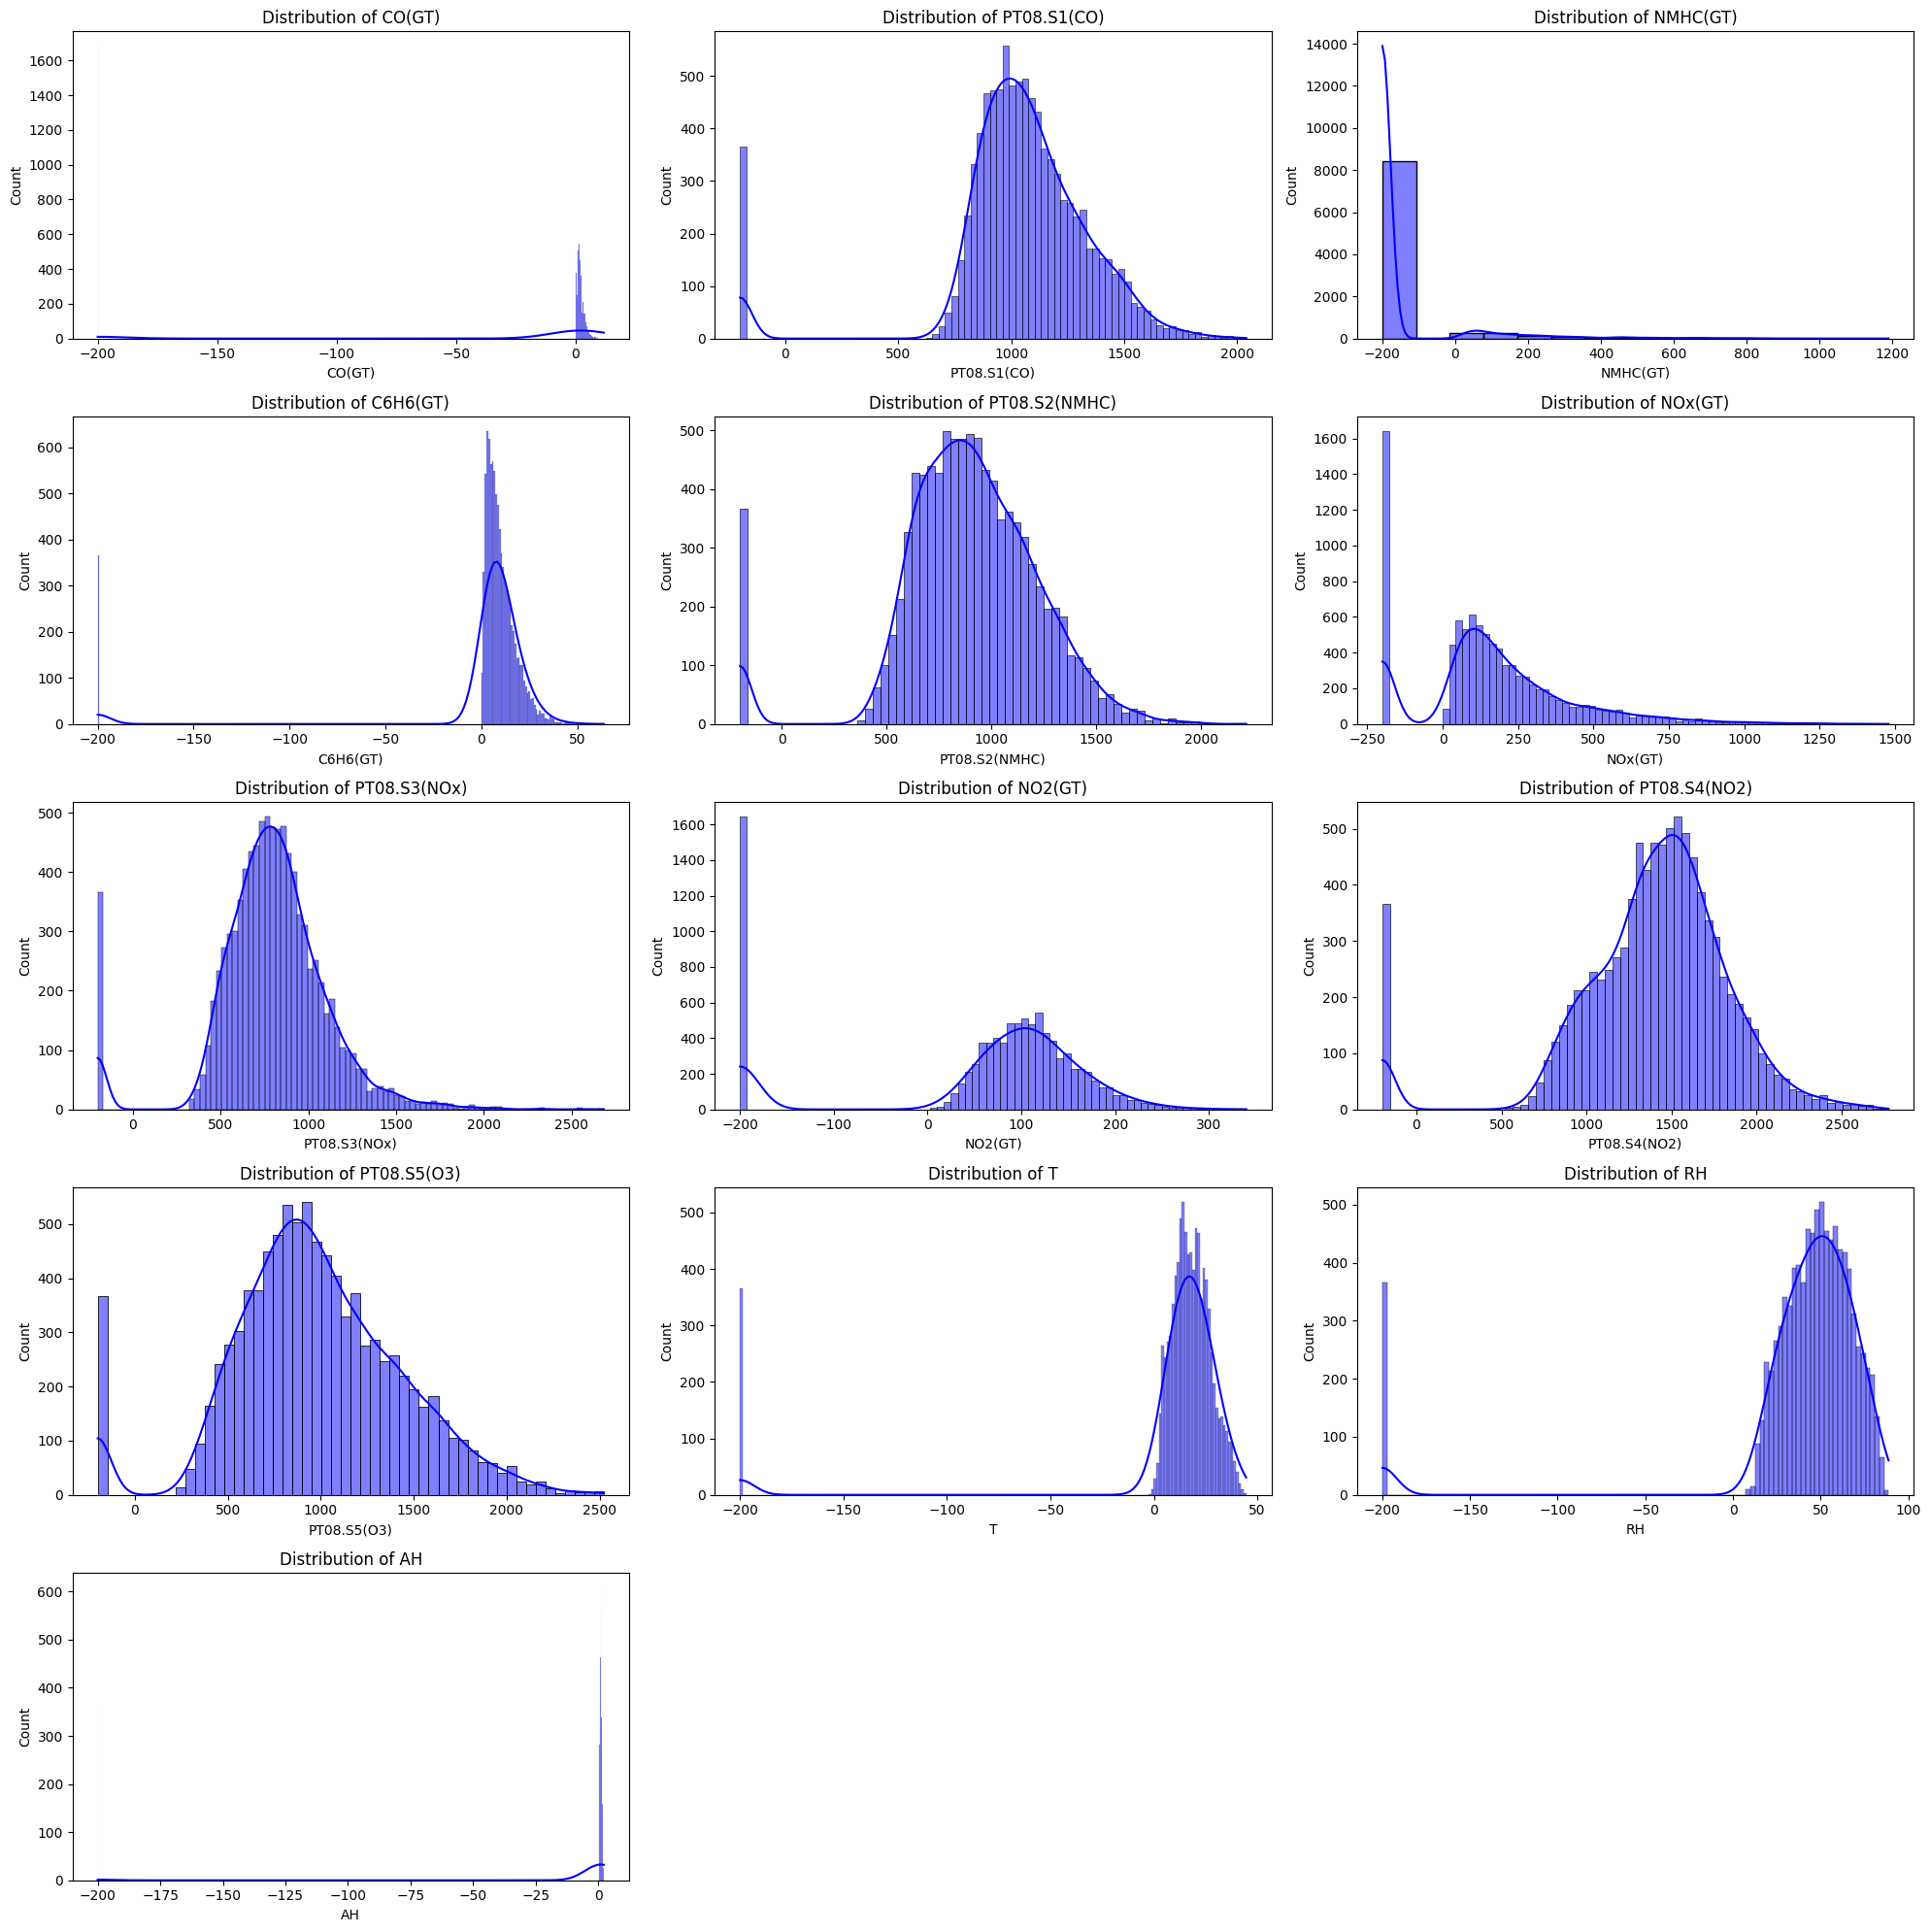

In [ ]:
## To understand the value distribution of each num_cols
plt.figure(figsize=(20, 20))

# Loop using index to arrange plots side-by-side
for i, col in enumerate(num_cols):
    plt.subplot(5, 3, i + 1)   # 5 rows, 3 columns grid
    sns.histplot(data=df, x=col, kde=True, color='blue')
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

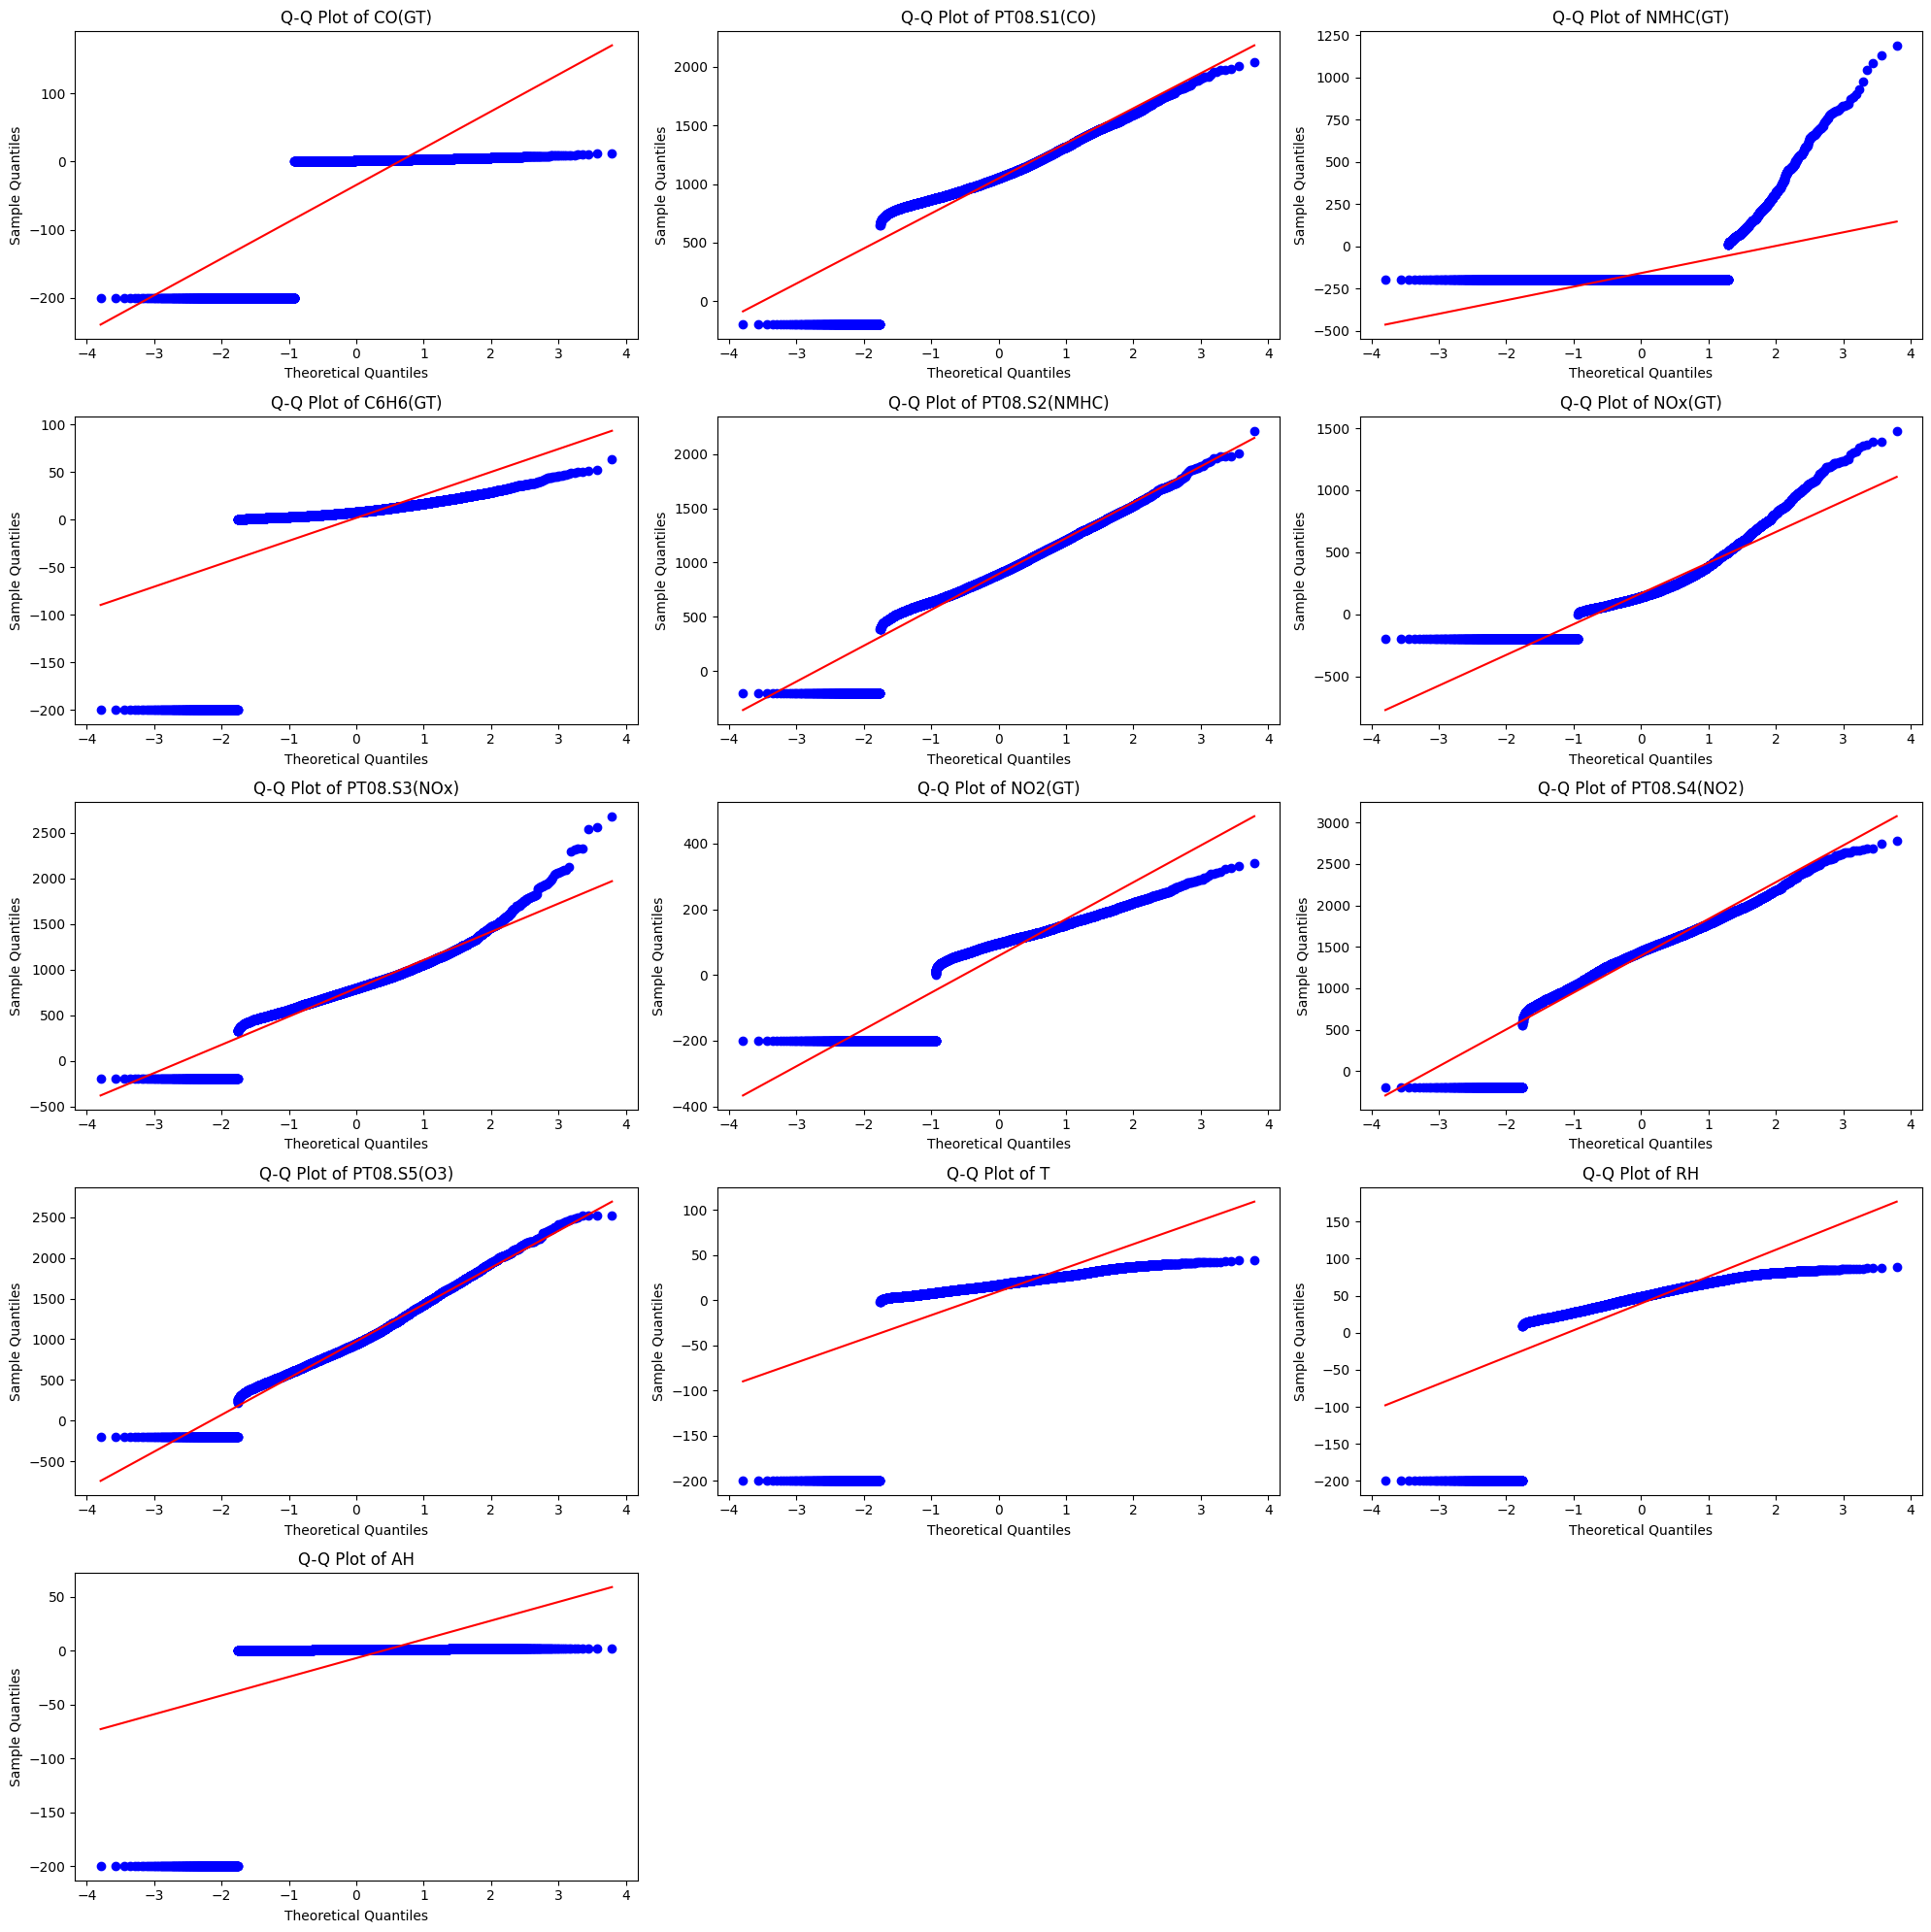

In [ ]:
# Plotting QQ plot to understand how does the data follows normal distribution.
plt.figure(figsize=(20, 20))

for i, col in enumerate(num_cols):
    plt.subplot(5, 3, i + 1)   # 5 rows, 3 columns grid

    # We use dropna() to ensure missing values don't break the plot
    stats.probplot(df[col].dropna(), dist="norm", plot=plt)

    plt.title(f'Q-Q Plot of {col}')
    plt.xlabel('Theoretical Quantiles')
    plt.ylabel('Sample Quantiles')

plt.tight_layout()
plt.show()

In [ ]:
# -200 is not a real measurement; it marks missing or
# faulty sensor readings. Leaving it as a number would corrupt
# all statistics, correlations, and model training.
df.replace(-200, np.nan, inplace=True)

In [ ]:
df.isna().sum()

,0
Date,0
Time,0
CO(GT),1683
PT08.S1(CO),366
NMHC(GT),8443
C6H6(GT),366
PT08.S2(NMHC),366
NOx(GT),1639
PT08.S3(NOx),366
NO2(GT),1642


In [ ]:
## Missing values %
missing_df = (df.isnull().sum() / len(df) * 100).round(2)
print(missing_df[missing_df > 0].sort_values(ascending=False))

NMHC(GT)         90.23
CO(GT)           17.99
NO2(GT)          17.55
NOx(GT)          17.52
PT08.S1(CO)       3.91
PT08.S2(NMHC)     3.91
C6H6(GT)          3.91
PT08.S3(NOx)      3.91
PT08.S4(NO2)      3.91
PT08.S5(O3)       3.91
T                 3.91
RH                3.91
AH                3.91
dtype: float64


In [ ]:
# With over 90% of the data missing, NMHC column is removed
df.drop(columns=['NMHC(GT)'], inplace=True)

In [ ]:
# Combine Date and Time columns into a single Datetime column
df['Datetime'] = pd.to_datetime(df['Date'].dt.strftime('%Y-%m-%d') + ' ' + df['Time'].astype(str))

# Set this new column as the DataFrame's index
df.set_index('Datetime', inplace=True)

cols_18_percent = ['CO(GT)', 'NO2(GT)', 'NOx(GT)']
df[cols_18_percent] = df[cols_18_percent].interpolate(method='time', limit=6)

In [ ]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
Datetime,,,,,,,,,,,,,,
2004-03-10 18:00:00,2004-03-10,18:00:00,2.6,1360.00,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
2004-03-10 19:00:00,2004-03-10,19:00:00,2.0,1292.25,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2004-03-10 20:00:00,2004-03-10,20:00:00,2.2,1402.00,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
2004-03-10 21:00:00,2004-03-10,21:00:00,2.2,1375.50,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
2004-03-10 22:00:00,2004-03-10,22:00:00,1.6,1272.25,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794


In [ ]:
cols_4_percent = ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)',
                  'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']

# Forward fill the minor gaps
df[cols_4_percent] = df[cols_4_percent].ffill()

In [ ]:
num_cols = num_cols.drop("NMHC(GT)")

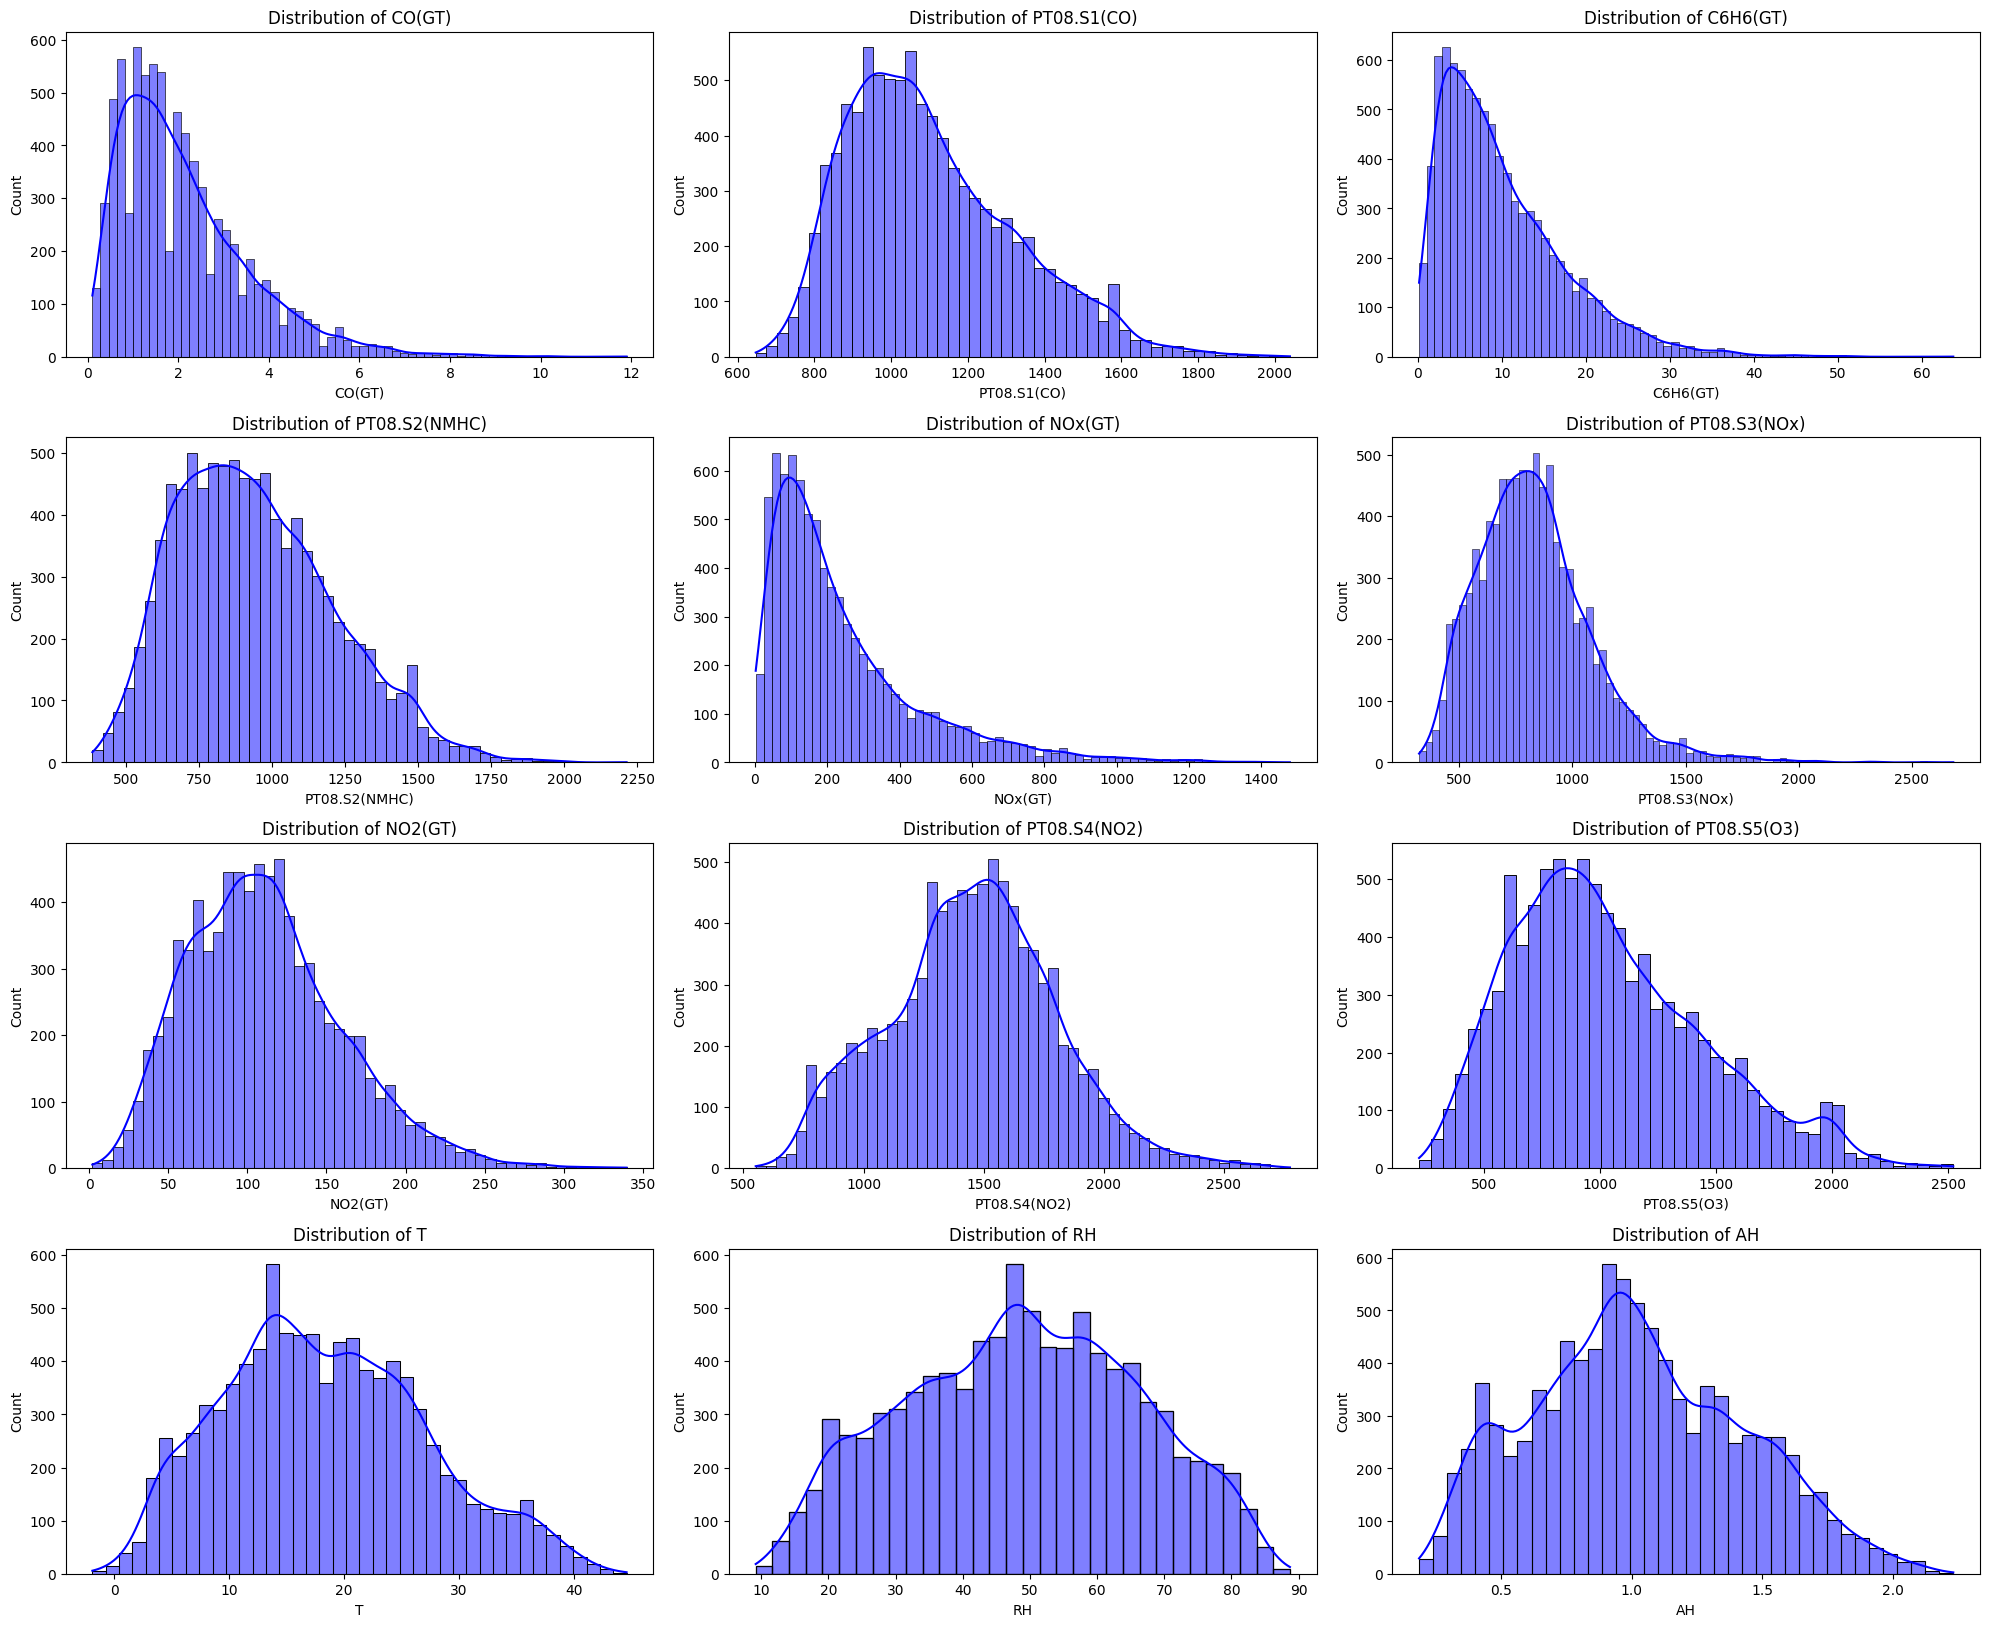

In [ ]:
## To understand the value distribution of each num_cols
plt.figure(figsize=(20, 20))

# Loop using index to arrange plots side-by-side
for i, col in enumerate(num_cols):
    plt.subplot(5, 3, i + 1)   # 5 rows, 3 columns grid
    sns.histplot(data=df, x=col, kde=True, color='blue')
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

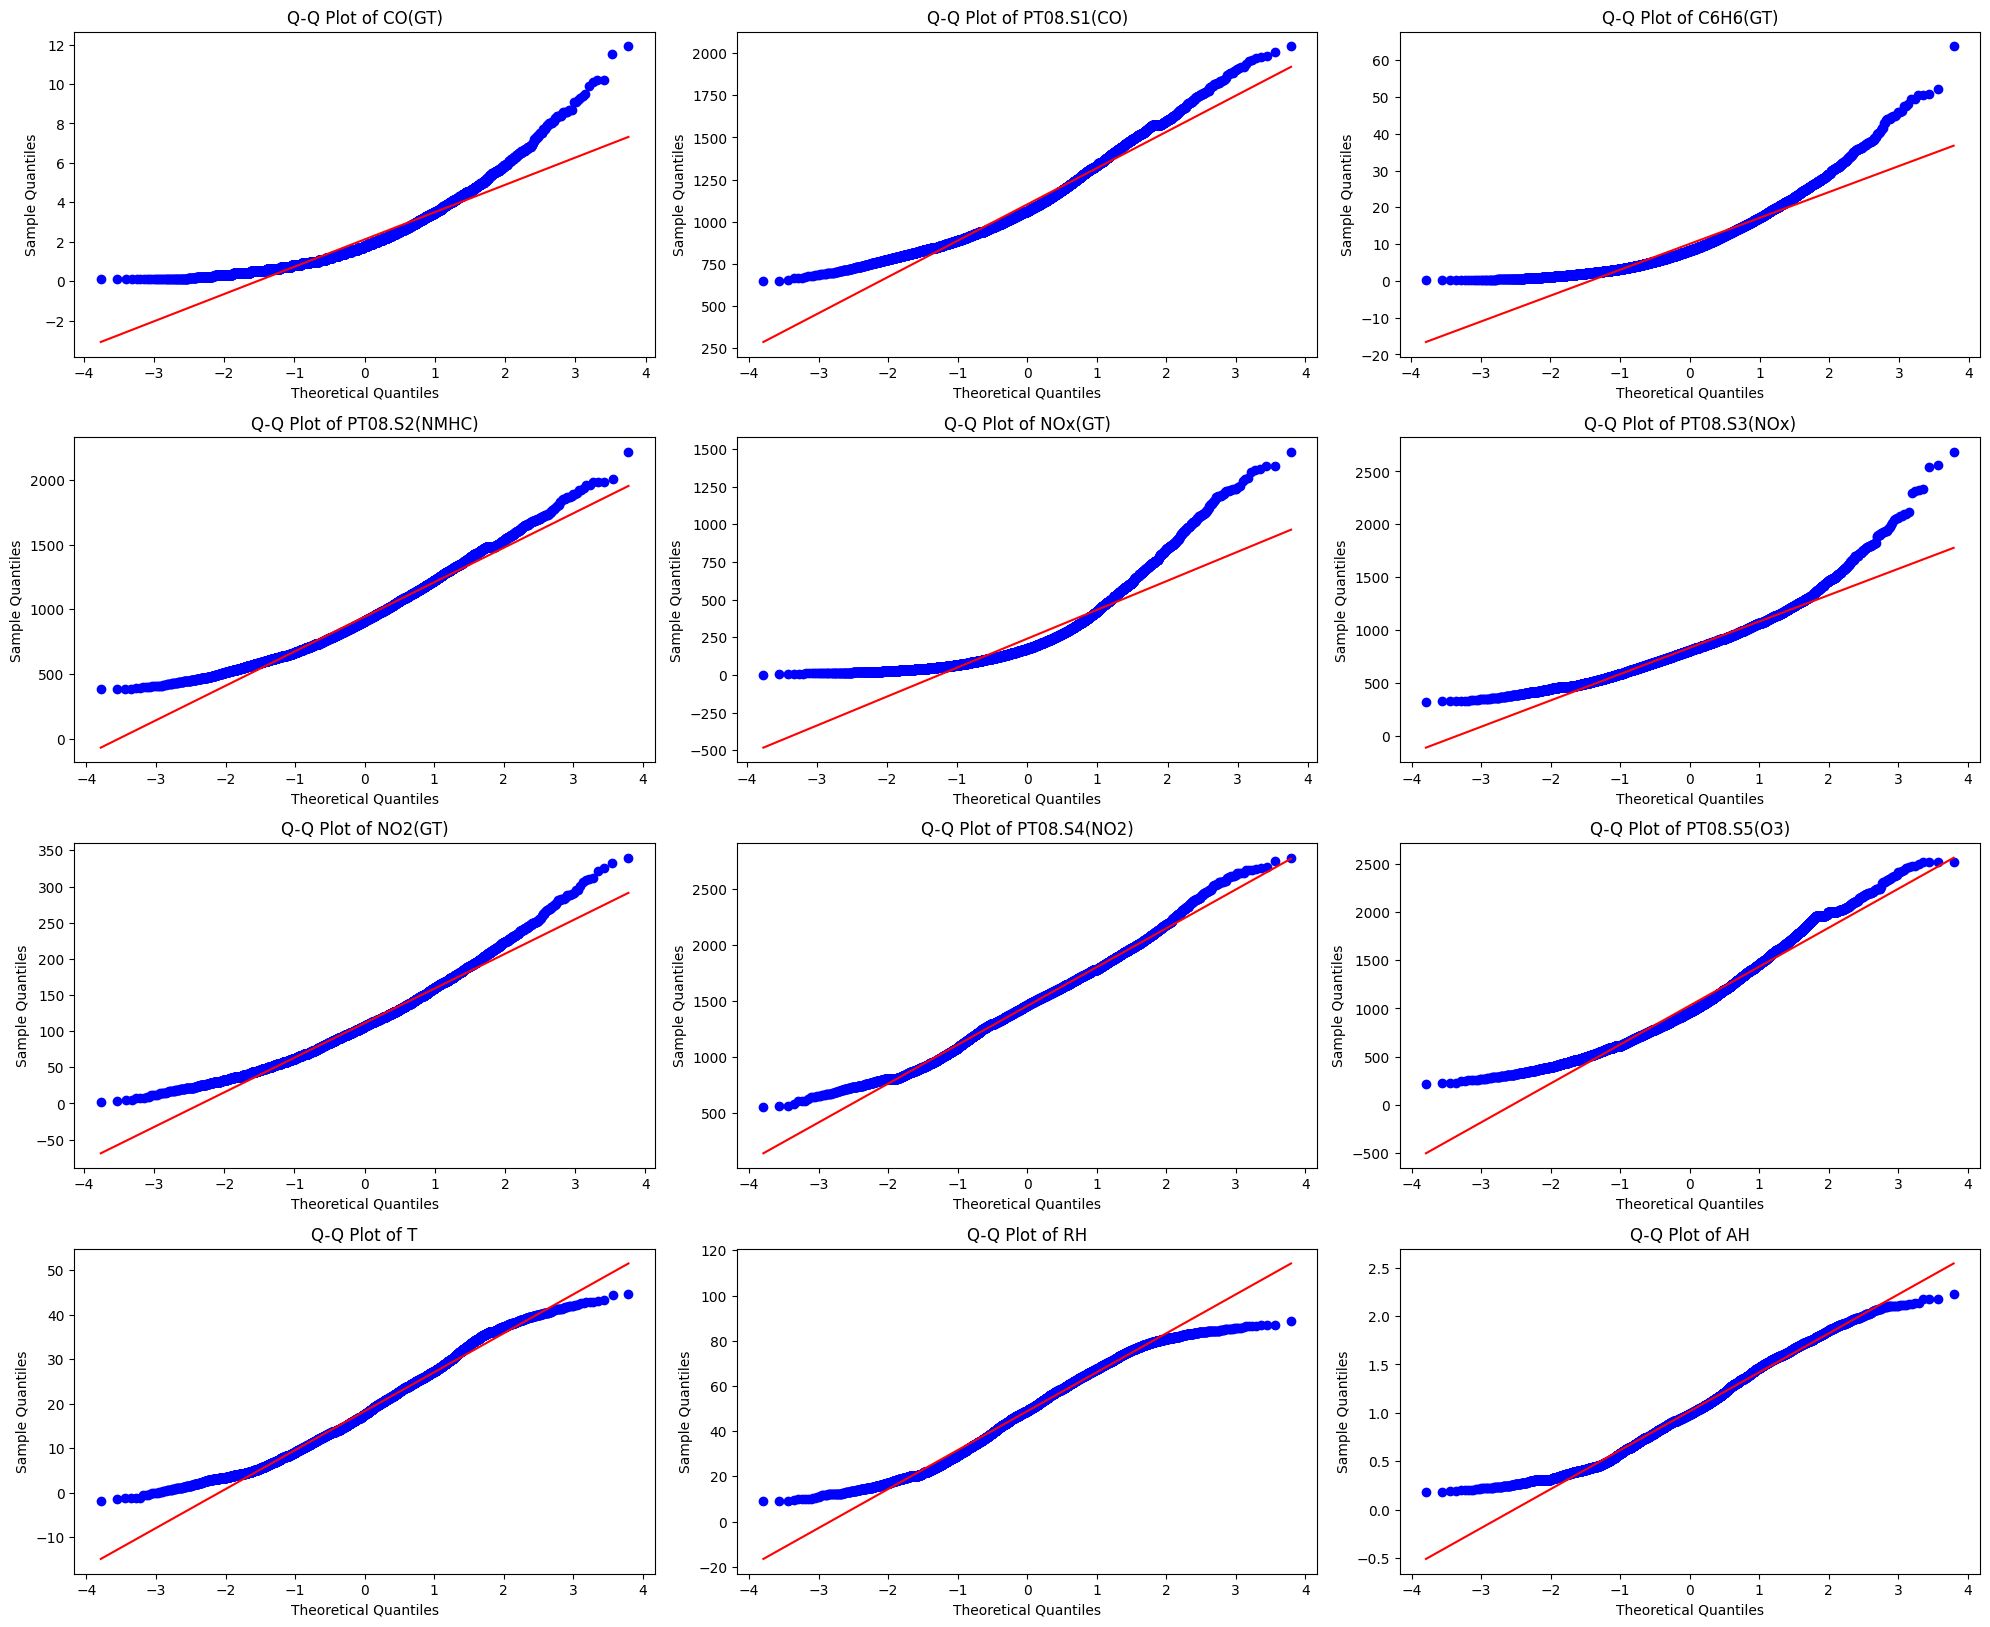

In [ ]:
# Plotting QQ plot to understand how well does the data follows normal distribution.
plt.figure(figsize=(20, 20))

for i, col in enumerate(num_cols):
    plt.subplot(5, 3, i + 1)   # 5 rows, 3 columns grid

    # We use dropna() to ensure missing values don't break the plot
    stats.probplot(df[col].dropna(), dist="norm", plot=plt)

    plt.title(f'Q-Q Plot of {col}')
    plt.xlabel('Theoretical Quantiles')
    plt.ylabel('Sample Quantiles')

plt.tight_layout()
plt.show()

In [ ]:
## Missing values % after
missing_df = (df.isnull().sum() / len(df) * 100).round(2)
print(missing_df[missing_df > 0].sort_values(ascending=False))

CO(GT)      14.25
NO2(GT)     12.72
NOx(GT)     12.70
C6H6(GT)     3.91
dtype: float64


In [ ]:
df['Hour'] = df.index.hour

#  Fill missing values using the average for that specific hour of the day
long_gap_cols = ['CO(GT)', 'NO2(GT)', 'NOx(GT)']

for col in long_gap_cols:
    df[col] = df[col].fillna(df.groupby('Hour')[col].transform('mean'))

# Check to ensure all NaNs are gone
print(df[long_gap_cols].isna().sum())

CO(GT)     0
NO2(GT)    0
NOx(GT)    0
dtype: int64


In [ ]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Hour
Datetime,,,,,,,,,,,,,,,
2004-03-10 18:00:00,2004-03-10,18:00:00,2.6,1360.00,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754,18
2004-03-10 19:00:00,2004-03-10,19:00:00,2.0,1292.25,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487,19
2004-03-10 20:00:00,2004-03-10,20:00:00,2.2,1402.00,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239,20
2004-03-10 21:00:00,2004-03-10,21:00:00,2.2,1375.50,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713,21
2004-03-10 22:00:00,2004-03-10,22:00:00,1.6,1272.25,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794,22


In [ ]:
num_cols = num_cols.drop("C6H6(GT)")
# Dropping this to prevent accidental imputation as this is the target feature.

In [ ]:
# Optional blocks if working with neural networks or Regressions

In [ ]:
# Also from the latest QQ plot, CO(GT), NOx(GT), and NO2(GT) blue dots
# bend severely away from the red line. This indicates extreme right skewness caused by heavy pollution spikes.

In [ ]:
# Apply log1p to heavily skewed columns
#skewed_cols = ['CO(GT)', 'NOx(GT)', 'NO2(GT)', 'C6H6(GT)']
#for col in skewed_cols:
#   df[f'{col}_log'] = np.log1p(df[col])

In [ ]:
df.isna().sum()

,0
Date,0
Time,0
CO(GT),0
PT08.S1(CO),0
C6H6(GT),366
PT08.S2(NMHC),0
NOx(GT),0
PT08.S3(NOx),0
NO2(GT),0
PT08.S4(NO2),0


In [ ]:
df.describe()

,Date,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Hour
count,9357,9357.000000,9357.000000,8991.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,2004-09-21 04:30:05.193972480,2.117021,1102.604396,10.082993,942.422741,240.795114,832.618539,111.058352,1452.890358,1030.388426,18.315768,48.814853,1.017382,11.498557
min,2004-03-10 00:00:00,0.100000,647.250000,0.149048,383.250000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.175000,0.184679,0.000000
25%,2004-06-16 00:00:00,1.090359,938.250000,4.436942,732.500000,100.334177,654.500000,76.000000,1227.750000,726.000000,11.875000,35.425000,0.726213,5.000000
50%,2004-09-21 00:00:00,1.900000,1061.500000,8.239851,910.500000,188.000000,806.750000,109.000000,1459.750000,963.750000,17.575000,48.925001,0.987539,11.000000
75%,2004-12-28 00:00:00,2.800000,1237.250000,13.988478,1117.250000,319.000000,967.500000,136.700000,1676.750000,1286.500000,24.325000,61.875000,1.306671,18.000000
max,2005-04-04 00:00:00,11.900000,2039.750000,63.741476,2214.000000,1479.000000,2682.750000,339.700000,2775.000000,2522.750000,44.600000,88.725000,2.231036,23.000000
std,NaN,1.386209,219.599578,7.449640,269.583076,199.621901,255.704654,46.290645,347.427351,410.906048,8.822898,17.354492,0.404829,6.923182


## Outlier Analysis and Removal

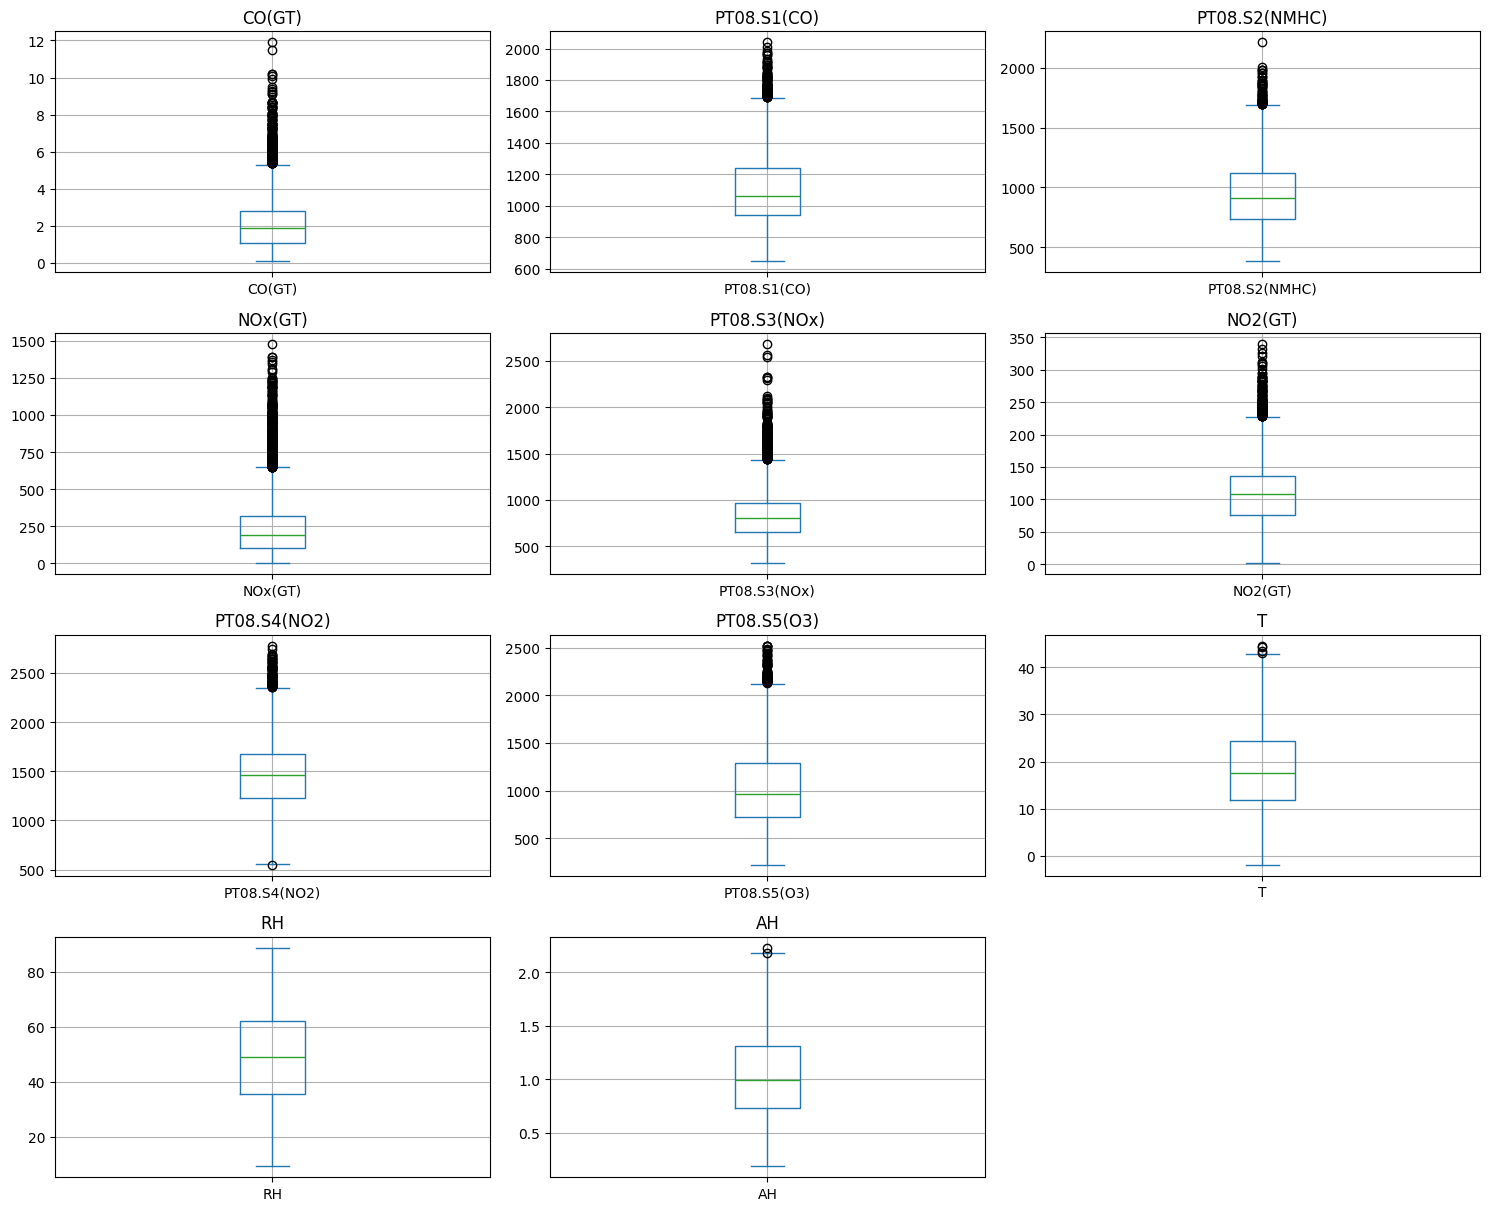

In [ ]:
# Outlier Visualization using Box-plot

plt.figure(figsize=(15,15))
for i, col in enumerate (num_cols, 1):
  plt.subplot(5,3,i)
  df[col].plot(kind='box')
  plt.title(col)
  plt.grid()

plt.tight_layout()

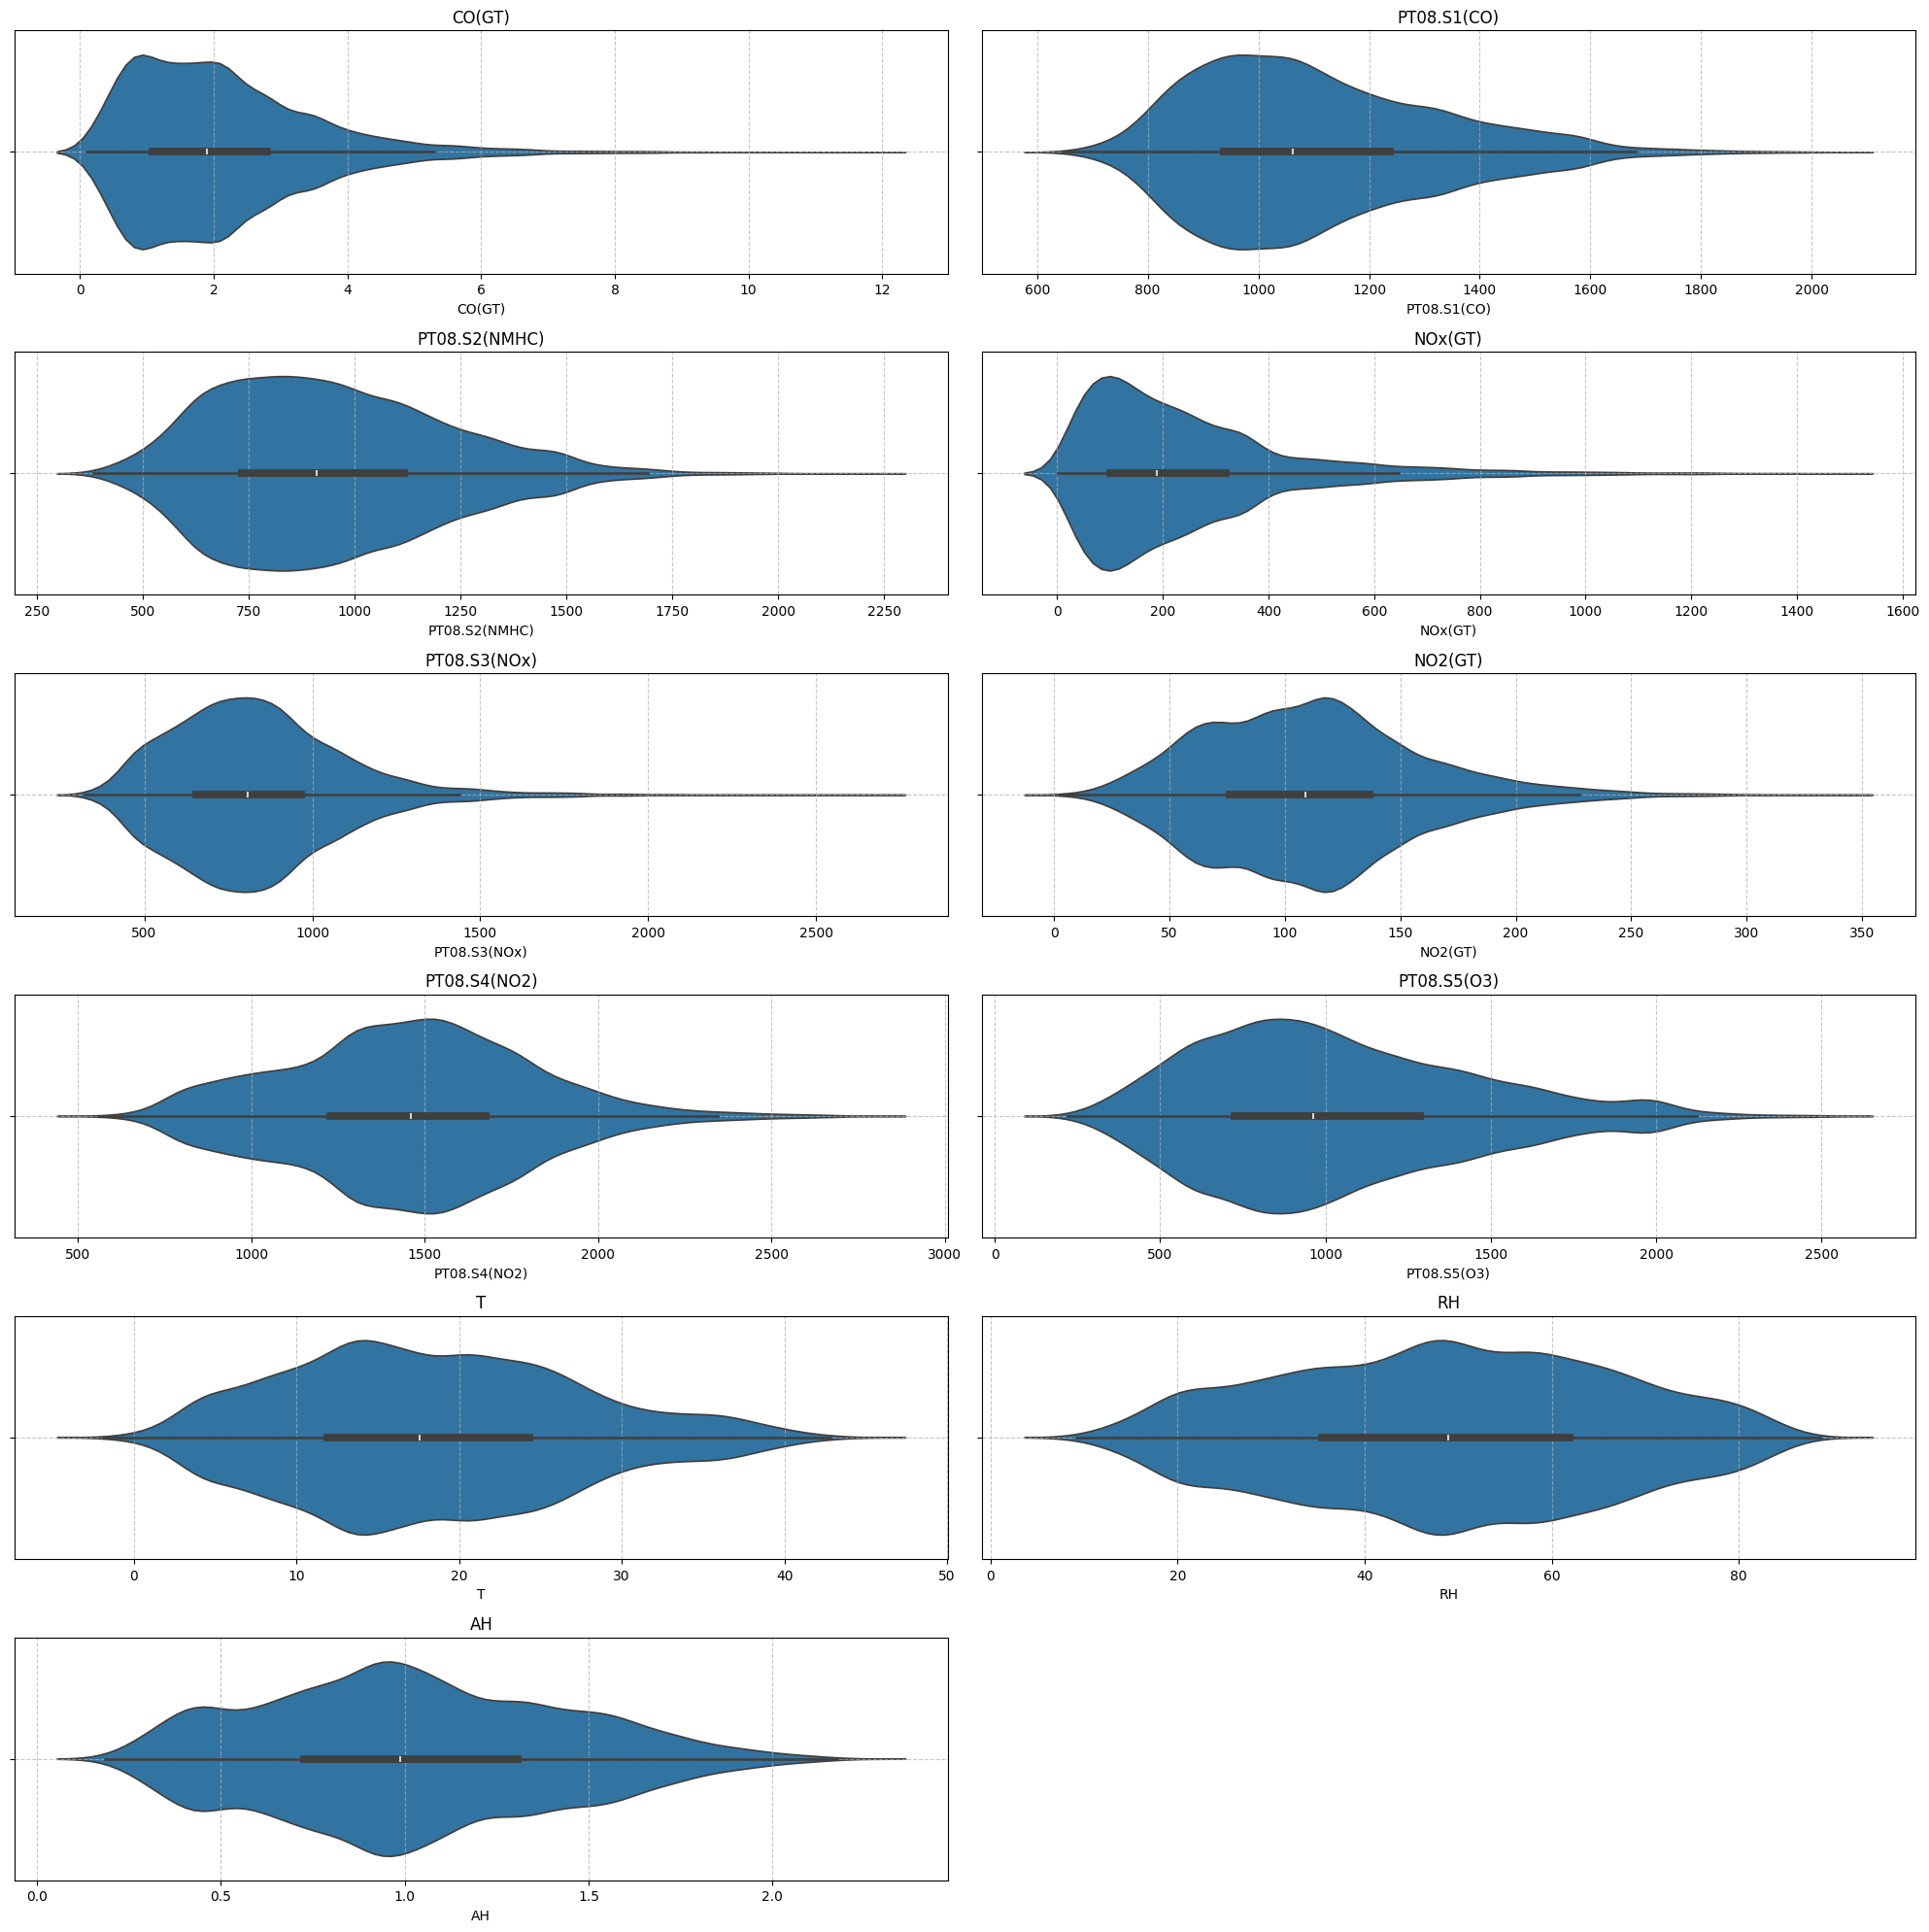

In [ ]:
# Outlier Visualization using violin-plot

plt.figure(figsize=(20,20))

for i, col in enumerate(num_cols, 1):
    plt.subplot(6, 2, i)
    sns.violinplot(
        x=df[col]
    )
    plt.title(col)
    plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# Outlier Count of each columns
for col in num_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1

  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR

  outliers = df[
      (df[col] < lower) |
      (df[col] > upper)
  ]

  print(f"{col}: {len(outliers)} outliers")

CO(GT): 299 outliers
PT08.S1(CO): 105 outliers
PT08.S2(NMHC): 61 outliers
NOx(GT): 489 outliers
PT08.S3(NOx): 240 outliers
NO2(GT): 156 outliers
PT08.S4(NO2): 95 outliers
PT08.S5(O3): 72 outliers
T: 4 outliers
RH: 0 outliers
AH: 2 outliers


Why Capping
 1. Time Series Continuity: Dropping rows with outliers would punch holes in our
   Datetime index. This would completely break our ability to calculate lag features
    or rolling averages, which require a continuous flow of time.
 2. Physical Reality: A massive spike in NOx(GT) is rarely a sensor error; it is
    usually a real world event (like a severe traffic jam). If we delete these rows,
   we artificially blind our model to high pollution events.
 3. Mathematical Stability: By capping (clipping) the values to a statistical upper
    limit, we acknowledge the extreme event happened, but prevent the astronomically
    high number from mathematically distorting the weights of our predictive model.

In [ ]:
cols_to_cap = [
    'CO(GT)', 'PT08.S1(CO)', 'PT08.S2(NMHC)', 'NOx(GT)',
    'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)',
    'T', 'AH'
]

In [ ]:
for col in cols_to_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower, upper=upper)

In [ ]:
## Outlier count after Capping
for col in num_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1

  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR

  outliers = df[
      (df[col] < lower) |
      (df[col] > upper)
  ]

  print(f"{col}: {len(outliers)} outliers")

CO(GT): 0 outliers
PT08.S1(CO): 0 outliers
PT08.S2(NMHC): 0 outliers
NOx(GT): 0 outliers
PT08.S3(NOx): 0 outliers
NO2(GT): 0 outliers
PT08.S4(NO2): 0 outliers
PT08.S5(O3): 0 outliers
T: 0 outliers
RH: 0 outliers
AH: 0 outliers


## Correlation and Heatmaps

In [ ]:
corr_matrix = df[num_cols].corr(method='pearson')
corr_matrix

,CO(GT),PT08.S1(CO),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
CO(GT),1.000000,0.817046,0.851089,0.789851,-0.720741,0.722437,0.573834,0.783626,0.048430,-0.012060,0.029264
PT08.S1(CO),0.817046,1.000000,0.896414,0.690892,-0.811653,0.620820,0.671857,0.902658,0.038133,0.119867,0.122378
PT08.S2(NMHC),0.851089,0.896414,1.000000,0.678403,-0.827534,0.621106,0.767451,0.877315,0.233231,-0.084294,0.174955
NOx(GT),0.789851,0.690892,0.678403,1.000000,-0.701501,0.793312,0.217892,0.747048,-0.237864,0.155190,-0.157204
PT08.S3(NOx),-0.720741,-0.811653,-0.827534,-0.701501,1.000000,-0.655404,-0.547217,-0.827630,-0.124307,-0.068987,-0.214876
NO2(GT),0.722437,0.620820,0.621106,0.793312,-0.655404,1.000000,0.154201,0.658382,-0.154948,-0.132790,-0.320828
PT08.S4(NO2),0.573834,0.671857,0.767451,0.217892,-0.547217,0.154201,1.000000,0.577635,0.563863,-0.016582,0.634478
PT08.S5(O3),0.783626,0.902658,0.877315,0.747048,-0.827630,0.658382,0.577635,1.000000,-0.043908,0.138105,0.056953
T,0.048430,0.038133,0.233231,-0.237864,-0.124307,-0.154948,0.563863,-0.043908,1.000000,-0.570680,0.654905
RH,-0.012060,0.119867,-0.084294,0.155190,-0.068987,-0.132790,-0.016582,0.138105,-0.570680,1.000000,0.180540


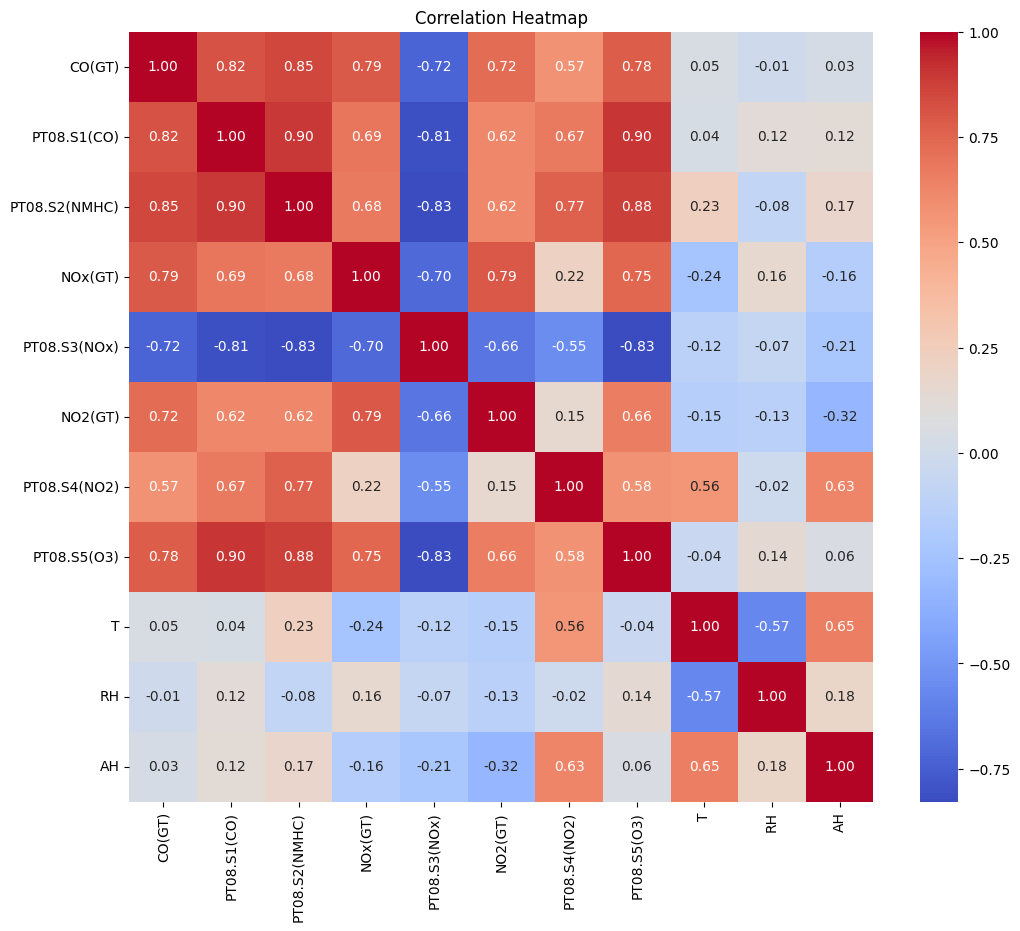

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

## Feature Engineering

In [ ]:
df['hour']       = df.index.hour
df['month']      = df.index.month
df['weekday']    = df.index.dayofweek  # 0 = Monday

In [ ]:
df['is_weekend']   = (df['weekday'] >= 5).astype(int)
df['is_daytime']   = ((df['hour'] >= 6) & (df['hour'] <= 18)).astype(int)
df['is_rush_hour'] = (((df['hour'] >= 7) & (df['hour'] <= 10)) | ((df['hour'] >= 17) & (df['hour'] <= 20))).astype(int)

In [ ]:
df['season'] = df['month'].map({
    12:1, 1:1, 2:1,  # Winter
    3:2, 4:2, 5:2,   # Spring
    6:3, 7:3, 8:3,   # Summer
    9:4, 10:4, 11:4  # Autumn
})

In [ ]:
# grab the previous hour's data.
df['C6H6_lag1'] = df['C6H6(GT)'].shift(1)
df['CO_lag1']   = df['CO(GT)'].shift(1)

In [ ]:
# Drop the first row which now has a NaN from the shift(1)
df.dropna(inplace=True)

print(f"Final shape: {df.shape}")# Shifting and rolling window calculations inherently introduce NaN values
# in the initial rows (due to lack of prior historical data).
# We drop these rows to ensure a clean dataset for model training.
df.dropna(inplace=True)

Final shape: (8974, 24)


In [ ]:
df.columns

Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)',
       'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)',
       'T', 'RH', 'AH', 'Hour', 'hour', 'month', 'weekday', 'is_weekend',
       'is_daytime', 'is_rush_hour', 'season', 'C6H6_lag1', 'CO_lag1'],
      dtype='object')

In [ ]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),...,Hour,hour,month,weekday,is_weekend,is_daytime,is_rush_hour,season,C6H6_lag1,CO_lag1
Datetime,,,,,,,,,,,,,,,,,,,,,
2004-03-10 19:00:00,2004-03-10,19:00:00,2.0,1292.25,9.397165,954.75,103.0,1173.75,92.0,1558.75,...,19,19,3,2,0,0,1,2,11.881723,2.6
2004-03-10 20:00:00,2004-03-10,20:00:00,2.2,1402.00,8.997817,939.25,131.0,1140.00,114.0,1554.50,...,20,20,3,2,0,0,1,2,9.397165,2.0
2004-03-10 21:00:00,2004-03-10,21:00:00,2.2,1375.50,9.228796,948.25,172.0,1092.00,122.0,1583.75,...,21,21,3,2,0,0,0,2,8.997817,2.2
2004-03-10 22:00:00,2004-03-10,22:00:00,1.6,1272.25,6.518224,835.50,131.0,1205.00,116.0,1490.00,...,22,22,3,2,0,0,0,2,9.228796,2.2
2004-03-10 23:00:00,2004-03-10,23:00:00,1.2,1197.00,4.741012,750.25,89.0,1336.50,96.0,1393.00,...,23,23,3,2,0,0,0,2,6.518224,1.6


In [ ]:
num_cols = [
    'CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)',
    'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)',
    'T', 'RH', 'AH', 'C6H6_lag1', 'CO_lag1'
]

# Even though these are stored as integers (1, 2, 3 or 0/1), they represent categories
cat_cols = [
    'hour', 'month', 'weekday', 'is_weekend',
    'is_daytime', 'is_rush_hour', 'season'
]

In [ ]:
# Correlation again after feature engineering

In [ ]:
corr_matrix = df[num_cols].corr(method='pearson')
corr_matrix

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,C6H6_lag1,CO_lag1
CO(GT),1.000000,0.839578,0.867600,0.879257,0.784003,-0.734064,0.715903,0.603916,0.815524,0.064462,-0.010959,0.047373,0.780866,0.846957
PT08.S1(CO),0.839578,1.000000,0.879405,0.893614,0.696360,-0.806572,0.640927,0.679062,0.900289,0.050117,0.115048,0.137261,0.759800,0.700166
C6H6(GT),0.867600,0.879405,1.000000,0.977003,0.681831,-0.769585,0.608185,0.760547,0.864498,0.198868,-0.060780,0.168866,0.839437,0.700607
PT08.S2(NMHC),0.879257,0.893614,0.977003,1.000000,0.690231,-0.827902,0.646710,0.776025,0.881680,0.243730,-0.092050,0.187910,0.840008,0.725641
NOx(GT),0.784003,0.696360,0.681831,0.690231,1.000000,-0.707313,0.788681,0.231695,0.761716,-0.226744,0.161612,-0.141672,0.613053,0.670734
PT08.S3(NOx),-0.734064,-0.806572,-0.769585,-0.827902,-0.707313,1.000000,-0.670981,-0.550922,-0.829392,-0.137334,-0.064535,-0.230915,-0.683985,-0.632037
NO2(GT),0.715903,0.640927,0.608185,0.646710,0.788681,-0.670981,1.000000,0.181153,0.689156,-0.138366,-0.131360,-0.305844,0.575028,0.647373
PT08.S4(NO2),0.603916,0.679062,0.760547,0.776025,0.231695,-0.550922,0.181153,1.000000,0.590526,0.567174,-0.033964,0.634108,0.646047,0.480348
PT08.S5(O3),0.815524,0.900289,0.864498,0.881680,0.761716,-0.829392,0.689156,0.590526,1.000000,-0.026005,0.125852,0.073394,0.787380,0.721144
T,0.064462,0.050117,0.198868,0.243730,-0.226744,-0.137334,-0.138366,0.567174,-0.026005,1.000000,-0.578482,0.656506,0.211427,0.072503


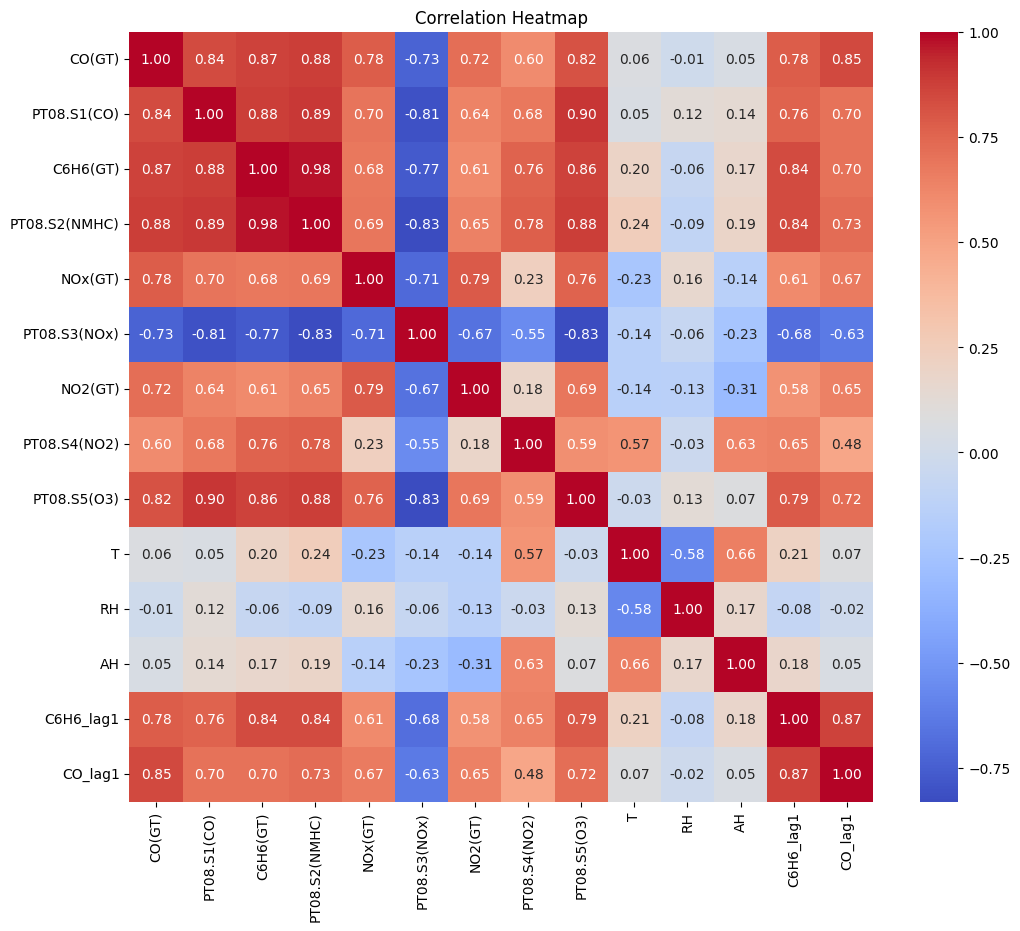

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

# Database

In [ ]:
import sqlite3

cols_to_drop = [col for col in ['Hour', 'C6H6_lag1', 'CO_lag1'] if col in df.columns]
df.drop(columns=cols_to_drop, inplace=True)

conn = sqlite3.connect('air_quality_project.db')
df.to_sql('sensor_logs', conn, if_exists='replace', index=True)

production_query = """
    SELECT
        "Datetime",
        "CO(GT)", "PT08.S1(CO)", "NOx(GT)", "PT08.S3(NOx)",
        "NO2(GT)", "PT08.S4(NO2)", "PT08.S5(O3)",
        "T", "RH", "AH",
        "hour", "month", "weekday",
        "is_weekend", "is_daytime", "is_rush_hour", "season",
        LAG("C6H6(GT)", 1) OVER (ORDER BY "Datetime") AS C6H6_lag1,
        "C6H6(GT)"                                    AS target_C6H6
    FROM sensor_logs
"""

ml_df = pd.read_sql_query(production_query, conn, index_col='Datetime')
ml_df.dropna(inplace=True)

target = 'target_C6H6'
X = ml_df.drop(columns=[target])
y = ml_df[target]

print("\nAll features in X:")
print(X.columns.tolist())


All features in X:
['CO(GT)', 'PT08.S1(CO)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'hour', 'month', 'weekday', 'is_weekend', 'is_daytime', 'is_rush_hour', 'season', 'C6H6_lag1']


In [ ]:
# No C6H6
assert 'C6H6(GT)' not in X.columns, "LEAK: Raw C6H6(GT) in X!"

#No direct benzene sensor
assert 'PT08.S2(NMHC)' not in X.columns, "LEAK: Direct benzene sensor in X!"

In [ ]:
split_index = int(len(ml_df) * 0.8)
X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print(f"\nX_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")


X_train : (7178, 18)
X_test  : (1795, 18)


In [ ]:
#---------------------------------------------------------------------------------------------------#

## Random Forests

In [ ]:
RANDOM_STATE = 42

n_estimators_list = [10, 50, 100, 200, 500]
max_depth_list = [2, 4, 8, 16, 32, 64, None]
min_samples_split_list = [2, 10, 30, 50, 100, 200]

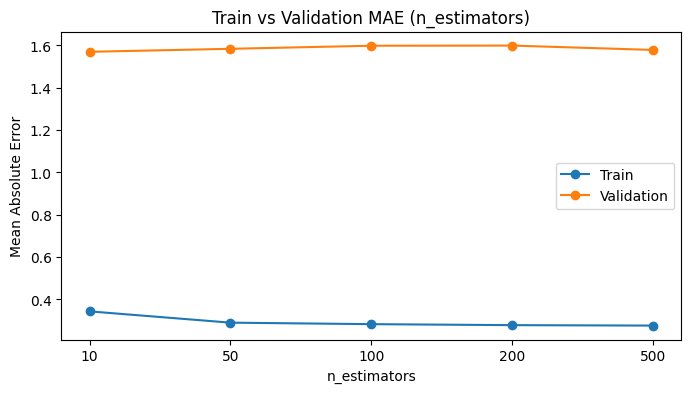

In [ ]:
mae_list_train = []
mae_list_val = []

for n_estimators in n_estimators_list:
  model = RandomForestRegressor(n_estimators=n_estimators, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)

  predictions_train = model.predict(X_train)
  predictions_val = model.predict(X_test)

  mae_list_train.append(mean_absolute_error(y_train, predictions_train))
  mae_list_val.append(mean_absolute_error(y_test, predictions_val))

plt.figure(figsize=(8,4))
plt.title('Train vs Validation MAE (n_estimators)')
plt.xlabel('n_estimators')
plt.ylabel('Mean Absolute Error')
plt.xticks(ticks=range(len(n_estimators_list)), labels=n_estimators_list)
plt.plot(mae_list_train, marker='o', label='Train')
plt.plot(mae_list_val, marker='o', label='Validation')
plt.legend()
plt.show()

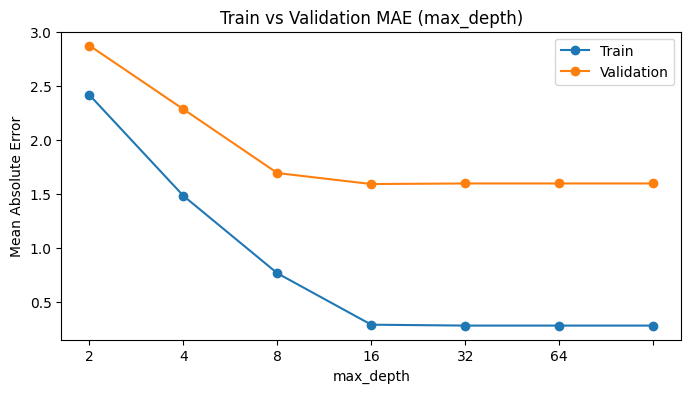

In [ ]:
mae_list_train = []
mae_list_val = []

for max_depth in max_depth_list:
  model = RandomForestRegressor(max_depth=max_depth, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)

  predictions_train = model.predict(X_train)
  predictions_val = model.predict(X_test)

  mae_list_train.append(mean_absolute_error(y_train, predictions_train))
  mae_list_val.append(mean_absolute_error(y_test, predictions_val))

plt.figure(figsize=(8,4))
plt.title('Train vs Validation MAE (max_depth)')
plt.xlabel('max_depth')
plt.ylabel('Mean Absolute Error')
plt.xticks(ticks=range(len(max_depth_list)), labels=max_depth_list)
plt.plot(mae_list_train, marker='o', label='Train')
plt.plot(mae_list_val, marker='o', label='Validation')
plt.legend()
plt.show()

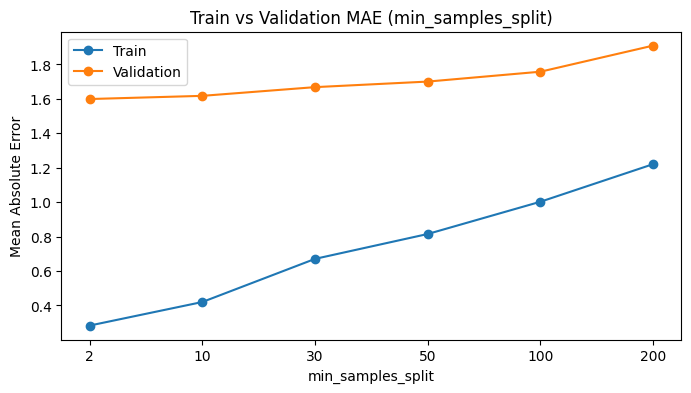

In [ ]:
mae_list_train = []
mae_list_val = []

for min_samples_split in min_samples_split_list:
  model = RandomForestRegressor(min_samples_split=min_samples_split, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)

  predictions_train = model.predict(X_train)
  predictions_val = model.predict(X_test)

  mae_list_train.append(mean_absolute_error(y_train, predictions_train))
  mae_list_val.append(mean_absolute_error(y_test, predictions_val))

plt.figure(figsize=(8,4))
plt.title('Train vs Validation MAE (min_samples_split)')
plt.xlabel('min_samples_split')
plt.ylabel('Mean Absolute Error')
plt.xticks(ticks=range(len(min_samples_split_list)), labels=min_samples_split_list)
plt.plot(mae_list_train, marker='o', label='Train')
plt.plot(mae_list_val, marker='o', label='Validation')
plt.legend()
plt.show()

In [ ]:
n_estimators = 200
max_depth = 8
min_samples_split = 10

In [ ]:
final_model = RandomForestRegressor(
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train, y_train)

train_predictions = final_model.predict(X_train)
test_predictions = final_model.predict(X_test)

print("Training:")
print("R2 Score:", r2_score(y_train, train_predictions))
print("RMSE:    ", np.sqrt(mean_squared_error(y_train, train_predictions)))
print("MAE:     ", mean_absolute_error(y_train, train_predictions))

print("\nTesting:")
print("R2 Score:", r2_score(y_test, test_predictions))
print("RMSE:    ", np.sqrt(mean_squared_error(y_test, test_predictions)))
print("MAE:     ", mean_absolute_error(y_test, test_predictions))

train_r2 = r2_score(y_train, train_predictions)
test_r2  = r2_score(y_test, test_predictions)
print(f"R2 Gap: {train_r2 - test_r2:.4f}")

Training:
R2 Score: 0.9802107194245794
RMSE:     1.0627170481533827
MAE:      0.7763796170772573

Testing:
R2 Score: 0.8849972900338142
RMSE:     2.209901765519342
MAE:      1.6818631608913015
R2 Gap: 0.0952


In [ ]:
#Overfitting

In [ ]:
print("Train target stats:")
print(y_train.describe())
print("\nTest target stats:")
print(y_test.describe())

Train target stats:
count    7178.000000
mean       10.631887
std         7.554973
min         0.212798
25%         4.982739
50%         8.823059
75%        14.530097
max        63.741476
Name: target_C6H6, dtype: float64

Test target stats:
count    1795.000000
mean        7.856834
std         6.518384
min         0.149048
25%         3.116651
50%         5.838871
75%        10.862993
max        42.956684
Name: target_C6H6, dtype: float64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

mean_baseline = DummyRegressor(strategy='mean')
mean_baseline.fit(X_train, y_train)
mean_preds = mean_baseline.predict(X_test)

median_baseline = DummyRegressor(strategy='median')
median_baseline.fit(X_train, y_train)
median_preds = median_baseline.predict(X_test)

print("Baseline 1 — mean:")
print(f"  R2   : {r2_score(y_test, mean_preds):.4f}")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_test, mean_preds)):.4f}")
print(f"  MAE  : {mean_absolute_error(y_test, mean_preds):.4f}")

print("\nBaseline 2 - median:")
print(f"  R2   : {r2_score(y_test, median_preds):.4f}")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_test, median_preds)):.4f}")
print(f"  MAE  : {mean_absolute_error(y_test, median_preds):.4f}")

Baseline 1 — mean:
  R2   : -0.0018
  RMSE : 7.6648
  MAE  : 5.8831

Baseline 2 - median:
  R2   : -0.0824
  RMSE : 7.9669
  MAE  : 5.7676


In [ ]:
print(y_train.describe())
print(y_test.describe())

count    7178.000000
mean       10.011053
std         7.385869
min         0.164946
25%         4.393367
50%         8.141759
75%        13.886582
max        63.741476
Name: target_C6H6, dtype: float64
count    1795.000000
mean       10.339478
std         7.659922
min         0.149048
25%         4.658770
50%         8.580856
75%        14.135147
max        52.054064
Name: target_C6H6, dtype: float64


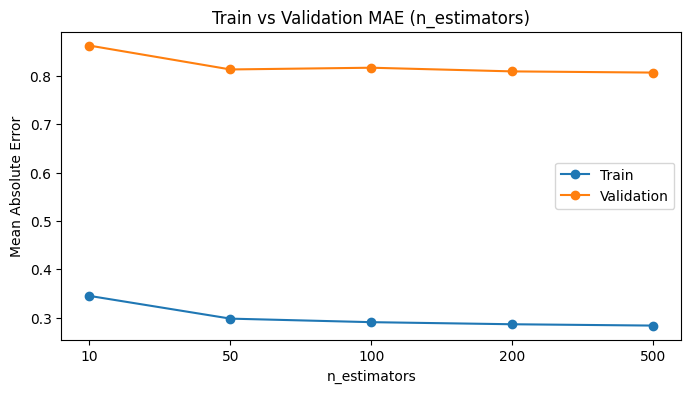

In [ ]:
mae_list_train = []
mae_list_val = []

for n_estimators in n_estimators_list:
  model = RandomForestRegressor(n_estimators=n_estimators, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)

  predictions_train = model.predict(X_train)
  predictions_val = model.predict(X_test)

  mae_list_train.append(mean_absolute_error(y_train, predictions_train))
  mae_list_val.append(mean_absolute_error(y_test, predictions_val))

plt.figure(figsize=(8,4))
plt.title('Train vs Validation MAE (n_estimators)')
plt.xlabel('n_estimators')
plt.ylabel('Mean Absolute Error')
plt.xticks(ticks=range(len(n_estimators_list)), labels=n_estimators_list)
plt.plot(mae_list_train, marker='o', label='Train')
plt.plot(mae_list_val, marker='o', label='Validation')
plt.legend()
plt.show()

In [ ]:
mae_list_train = []
mae_list_val = []

for max_depth in max_depth_list:
  model = RandomForestRegressor(max_depth=max_depth, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)

  predictions_train = model.predict(X_train)
  predictions_val = model.predict(X_test)

  mae_list_train.append(mean_absolute_error(y_train, predictions_train))
  mae_list_val.append(mean_absolute_error(y_test, predictions_val))

plt.figure(figsize=(8,4))
plt.title('Train vs Validation MAE (max_depth)')
plt.xlabel('max_depth')
plt.ylabel('Mean Absolute Error')
plt.xticks(ticks=range(len(max_depth_list)), labels=max_depth_list)
plt.plot(mae_list_train, marker='o', label='Train')
plt.plot(mae_list_val, marker='o', label='Validation')
plt.legend()
plt.show()

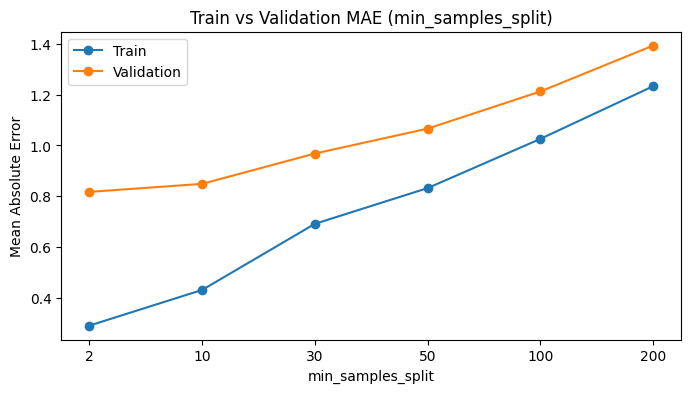

In [75]:
mae_list_train = []
mae_list_val = []

for min_samples_split in min_samples_split_list:
  model = RandomForestRegressor(min_samples_split=min_samples_split, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)

  predictions_train = model.predict(X_train)
  predictions_val = model.predict(X_test)

  mae_list_train.append(mean_absolute_error(y_train, predictions_train))
  mae_list_val.append(mean_absolute_error(y_test, predictions_val))

plt.figure(figsize=(8,4))
plt.title('Train vs Validation MAE (min_samples_split)')
plt.xlabel('min_samples_split')
plt.ylabel('Mean Absolute Error')
plt.xticks(ticks=range(len(min_samples_split_list)), labels=min_samples_split_list)
plt.plot(mae_list_train, marker='o', label='Train')
plt.plot(mae_list_val, marker='o', label='Validation')
plt.legend()
plt.show()

In [76]:
final_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train, y_train)

train_predictions = final_model.predict(X_train)
test_predictions  = final_model.predict(X_test)

print("Training:")
print("R2 Score:", r2_score(y_train, train_predictions))
print("RMSE:    ", np.sqrt(mean_squared_error(y_train, train_predictions)))
print("MAE:     ", mean_absolute_error(y_train, train_predictions))

print("\nTesting:")
print("R2 Score:", r2_score(y_test, test_predictions))
print("RMSE:    ", np.sqrt(mean_squared_error(y_test, test_predictions)))
print("MAE:     ", mean_absolute_error(y_test, test_predictions))

Training:
R2 Score: 0.9795706098572722
RMSE:     1.0555992554776996
MAE:      0.7691746190903576

Testing:
R2 Score: 0.9565979844675406
RMSE:     1.595358542755732
MAE:      1.0274861366592147


In [77]:
train_r2 = r2_score(y_train, train_predictions)
test_r2  = r2_score(y_test, test_predictions)
print(f"R2 Gap: {train_r2 - test_r2:.4f}")

R2 Gap: 0.0230


## XGBoost

In [78]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.15,
    random_state=42,
    shuffle=True
)

print(f"Train : {X_tr.shape}  mean={y_tr.mean():.2f}")
print(f"Val   : {X_val.shape}  mean={y_val.mean():.2f}")
print(f"Test  : {X_test.shape}  mean={y_test.mean():.2f}")

Train : (6101, 18)  mean=10.01
Val   : (1077, 18)  mean=10.00
Test  : (1795, 18)  mean=10.34


In [79]:
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=8,
    verbosity=0,
    random_state=RANDOM_STATE,
    reg_lambda=1.5,
    early_stopping_rounds=10
)

xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)],
    verbose=False
)

y_train_pred = xgb_model.predict(X_tr)
y_val_pred   = xgb_model.predict(X_val)
y_test_pred  = xgb_model.predict(X_test)

In [80]:
print("Training")
print(f"R2 Score : {r2_score(y_tr, y_train_pred):.4f}")
print(f"RMSE     : {np.sqrt(mean_squared_error(y_tr, y_train_pred)):.4f}")
print(f"MAE      : {mean_absolute_error(y_tr, y_train_pred):.4f}\n")

print("Validation")
print(f"R2 Score : {r2_score(y_val, y_val_pred):.4f}")
print(f"RMSE     : {np.sqrt(mean_squared_error(y_val, y_val_pred)):.4f}")
print(f"MAE      : {mean_absolute_error(y_val, y_val_pred):.4f}\n")

print("Testing")
print(f"R2 Score : {r2_score(y_test, y_test_pred):.4f}")
print(f"RMSE     : {np.sqrt(mean_squared_error(y_test, y_test_pred)):.4f}")
print(f"MAE      : {mean_absolute_error(y_test, y_test_pred):.4f}")


Training
R2 Score : 0.9997
RMSE     : 0.1185
MAE      : 0.0876

Validation
R2 Score : 0.9849
RMSE     : 0.9161
MAE      : 0.6247

Testing
R2 Score : 0.9810
RMSE     : 1.0564
MAE      : 0.6638


In [81]:
y_test_pred = xgb_model.predict(X_test)
gap = r2_score(y_tr, xgb_model.predict(X_tr)) - r2_score(y_test, y_test_pred)
print(f"R2 Gap (train vs test): {gap:.4f}")

R2 Gap (train vs test): 0.0188


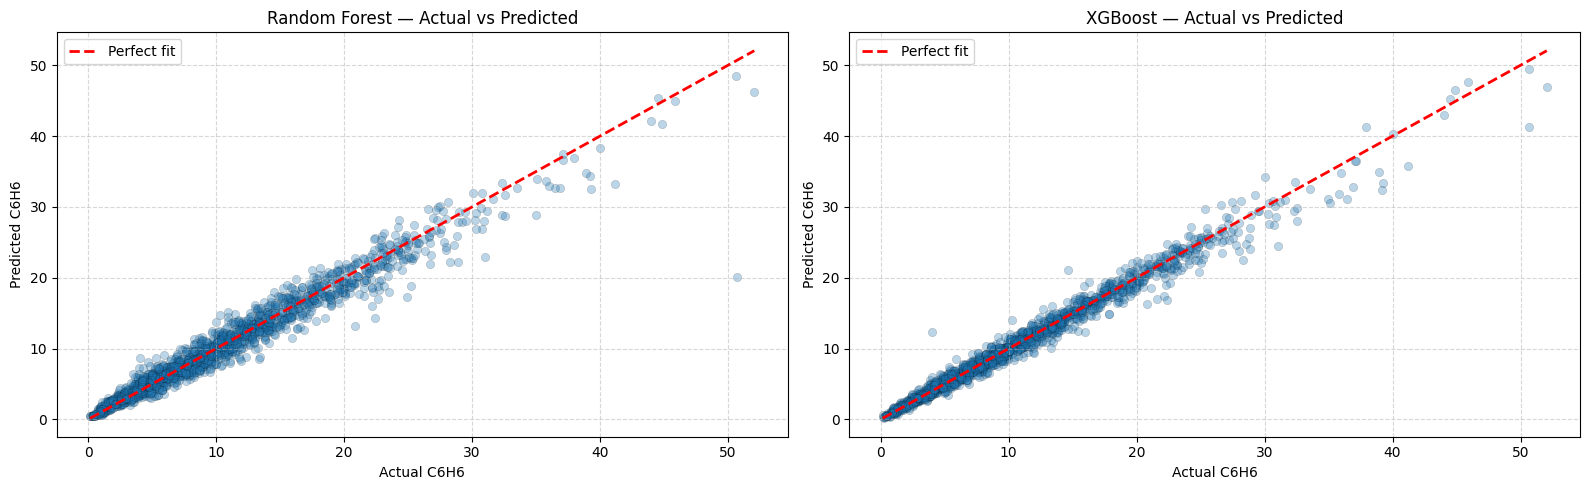

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, preds, title in zip(
    axes,
    [test_predictions, y_test_pred],
    ['Random Forest', 'XGBoost']
):
    ax.scatter(y_test, preds, alpha=0.3, edgecolors='k', linewidths=0.3)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect fit')
    ax.set_xlabel('Actual C6H6')
    ax.set_ylabel('Predicted C6H6')
    ax.set_title(f'{title} — Actual vs Predicted')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
comparison_data = {
  "Model": ["Baseline (Mean)", "Random Forest", "XGBoost"],
  "R2 Score": [
      r2_score(y_test, mean_preds),
      r2_score(y_test, test_predictions),
      r2_score(y_test, y_test_pred)
  ],
  "RMSE": [
      np.sqrt(mean_squared_error(y_test, mean_preds)),
      np.sqrt(mean_squared_error(y_test, test_predictions)),
      np.sqrt(mean_squared_error(y_test, y_test_pred))
  ],
  "MAE": [
      mean_absolute_error(y_test, mean_preds),
      mean_absolute_error(y_test, test_predictions),
      mean_absolute_error(y_test, y_test_pred)
  ]
}

comparison_df = pd.DataFrame(comparison_data).round(4)

print("Model Performances (Test Set)")
print(comparison_df.to_string(index=False))

##Forecasting

In [84]:
pip install fastapi uvicorn pydantic streamlit nest_asyncio pyngrok joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 89.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 115.1 MB/s eta 0:00:00


In [89]:
import joblib

# Option A: If you want to save your Random Forest Model
# (Make sure 'rf_model' matches the variable name you used to train it)
joblib.dump(xgb_model, 'benzene_model.pkl')

# Option B: If you want to save your XGBoost Model instead
# (Make sure 'xgb_model' matches the variable name you used to train it)
# joblib.dump(xgb_model, 'benzene_model.pkl')

print("Success! benzene_model.pkl has been created and saved to your workspace.")

Success! benzene_model.pkl has been created and saved to your workspace.


In [90]:
%%writefile app.py
import streamlit as st
import numpy as np
import joblib

# 1. Load the model
model = joblib.load('benzene_model.pkl')

# 2. Set up the UI Header
st.set_page_config(page_title="Air Quality Predictor", layout="centered")
st.title("🏭 Benzene Concentration Predictor")
st.write("Input real-time sensor measurements below to predict atmospheric Benzene ($\mu g/m^3$).")

st.markdown("---")

# 3. Create Inputs for the Features Your Model Needs
col1, col2 = st.columns(2)

with col1:
    co = st.number_input("CO(GT) - Carbon Monoxide", value=2.1, step=0.1)
    pt08_s1 = st.number_input("PT08.S1(CO) Tin Oxide", value=1102.0, step=10.0)
    nox = st.number_input("NOx(GT) Nitrogen Oxides", value=240.0, step=5.0)
    no2 = st.number_input("NO2(GT) Nitrogen Dioxide", value=111.0, step=5.0)
    t = st.slider("Temperature (°C)", min_value=-5.0, max_value=50.0, value=18.0)

with col2:
    pt08_s2 = st.number_input("PT08.S2(NMHC) Titania", value=942.0, step=10.0)
    pt08_s3 = st.number_input("PT08.S3(NOx) Tungsten Oxide", value=832.0, step=10.0)
    pt08_s4 = st.number_input("PT08.S4(NO2) Tungsten Oxide", value=1452.0, step=10.0)
    pt08_s5 = st.number_input("PT08.S5(O3) Indium Oxide", value=1030.0, step=10.0)
    rh = st.slider("Relative Humidity (%)", min_value=0.0, max_value=100.0, value=48.0)

# --- Define the missing features to reach the required 18 features ---
ah = 1.0
hour = 12
month = 3
weekday = 2      # 2 = Wednesday
is_weekend = 0
is_daytime = 1
is_rush_hour = 1
season = 2       # 2 = Spring
c6h6_lag1 = 10.0 # Placeholder for previous hour's benzene

st.markdown("---")

# 4. Handle Prediction Logic
if st.button("🚀 Predict Benzene Levels", type="primary"):
    # RE-ORDERED ARRAY: Matches your exact 18-column notebook layout sequence
    input_features = np.array([[
        co, pt08_s1, nox, pt08_s3, no2, pt08_s4, pt08_s5, t, rh, ah,
        hour, month, weekday, is_weekend, is_daytime, is_rush_hour, season, c6h6_lag1
    ]])

    # Run prediction
    prediction = model.predict(input_features)[0]

    # Display Result
    st.metric(label="Predicted C6H6 Concentration", value=f"{prediction:.2f} μg/m³")

    if prediction > 10.0:
        st.error("⚠️ High Pollution Warning: Detected values exceed baseline conditions.")
    else:
        st.success("✅ Normal Range: Air sample matches clean baseline patterns.")

Overwriting app.py


In [88]:
# 1. Install localtunnel
!npm install -g localtunnel

# 2. Print your Tunnel Password (Your Colab public IP)
print("\n--- COPY THIS PASSWORD FOR LOCALTUNNEL ---")
!curl ipv4.icanhazip.com
print("------------------------------------------\n")

# 3. Run Streamlit AND localtunnel together safely
!streamlit run app.py --server.port 8501 & npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇
added 22 packages in 2s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇
--- COPY THIS PASSWORD FOR LOCALTUNNEL ---
34.7.178.76
------------------------------------------

⠙⠹⠸⠼⠴

<unknown>:11: SyntaxWarning: invalid escape sequence '\m'
your url is: https://pretty-jeans-drop.loca.lt
2026-06-23 04:47:52.608 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.7.178.76:8501

  Stopping...
^C
